In [1]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# Load wrangled optimisation outputs.
experiment_df = pl.read_parquet('./Results/optimisation_experiments.parquet')
best_policy_df = pl.read_parquet('./Results/optimisation_best_policies.parquet')
outcomes_df = pl.read_parquet('./Results/optimisation_outcomes.parquet')

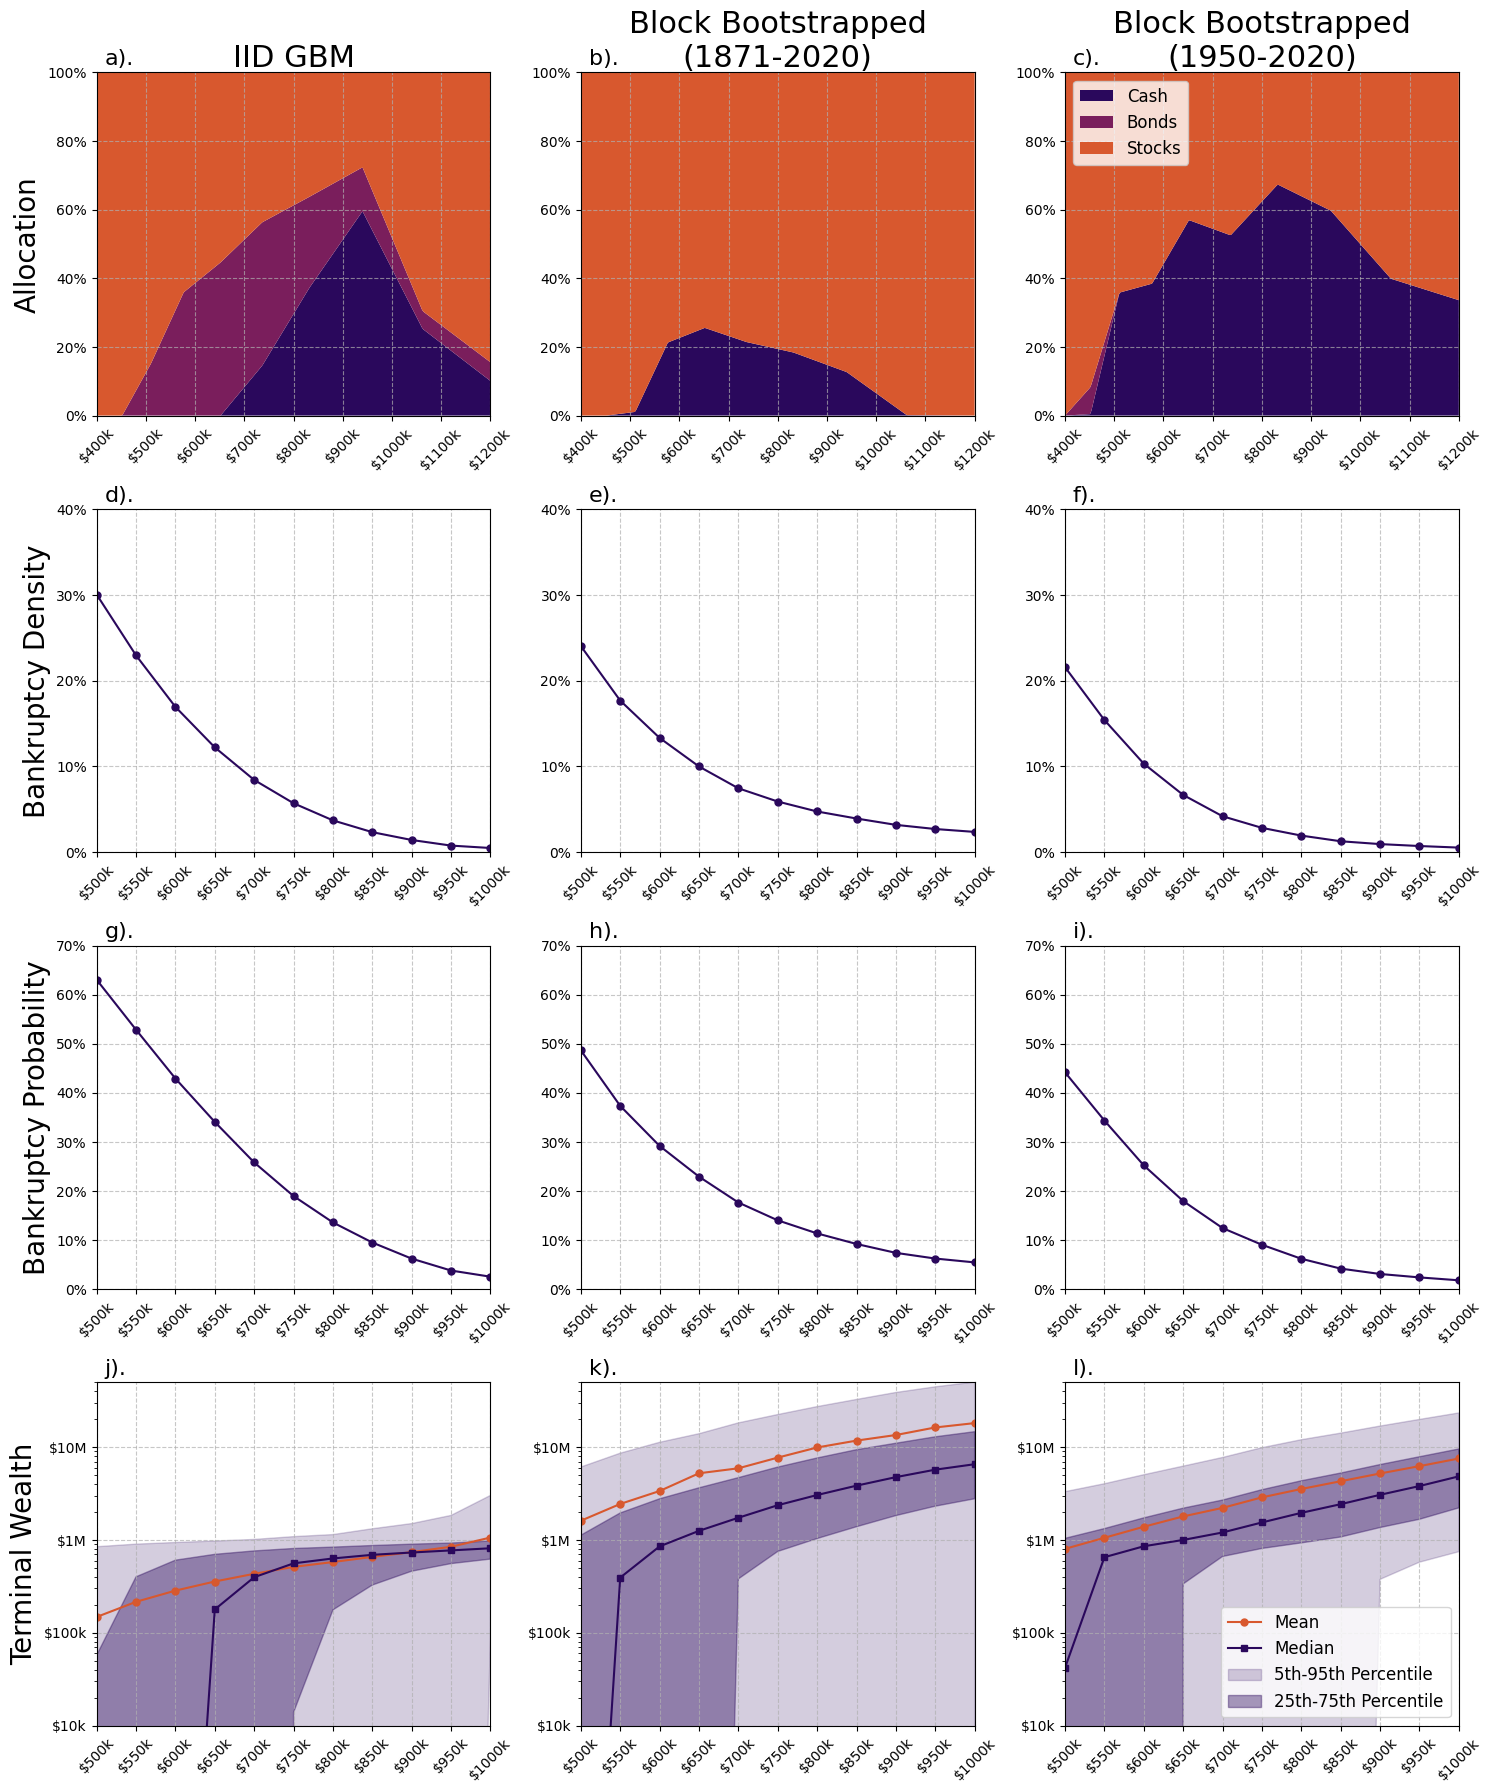

In [2]:
"""
plot layout:
Titles -> sampler name
Row 1: Allocation for each simulated initial wealth
Row 2: Bankruptcy density for each simulated initial wealth
Row 3: Bankruptcy probability for each simulated initial wealth
Row 4: Mean terminal wealth for each simulated initial wealth
"""

N_WEALTH_NODES_TO_PLOT = 10
N_TIME_NODES_TO_PLOT = 1

# Use full wealth range for allocation-policy visualisation.
WEALTH_PLOT_MIN = 400_000
WEALTH_PLOT_MAX = 1_200_000
ALLOCATION_X = np.linspace(WEALTH_PLOT_MIN, WEALTH_PLOT_MAX, 300)

policy_data = best_policy_df.join(
    experiment_df,
    on='experiment_file',
).filter(
    (pl.col('n_wealth_nodes') == N_WEALTH_NODES_TO_PLOT)
    & (pl.col('n_time_nodes') == N_TIME_NODES_TO_PLOT)
    & (pl.col('initial_wealth').is_null())
)

outcome_data = outcomes_df.join(
    experiment_df,
    on='experiment_file',
).filter(
    (pl.col('n_wealth_nodes') == N_WEALTH_NODES_TO_PLOT)
    & (pl.col('n_time_nodes') == N_TIME_NODES_TO_PLOT)
    & (pl.col('initial_wealth').is_null())
)

samplers_to_plot = [
    'cholesky',
    'block_bootstrapped',
    'block_bootstrapped_1950',
]

RETURN_SAMPLER_DISPLAY_NAMES = {
    'cholesky': 'IID GBM',
    'block_bootstrapped': 'Block Bootstrapped\n(1871-2020)',
    'block_bootstrapped_1950': 'Block Bootstrapped\n(1950-2020)',
}

colors = {
    'Cash': '#2a085c',
    'Bonds': '#7a1e5c',
    'Stocks': '#d8582e',
}

percent_formatter = plt.FuncFormatter(lambda y, _: f'{y:.0%}')

def _currency_formatter(y: float, _: int) -> str:
    if not np.isfinite(y) or y <= 0:
        return ''
    if y >= 1_000_000:
        return f'${y / 1_000_000:.0f}M'
    if y >= 1_000:
        return f'${y / 1_000:.0f}k'
    return f'${y:.0f}'

currency_formatter = plt.FuncFormatter(_currency_formatter)

fig, axes = plt.subplots(
    nrows=4,
    ncols=len(samplers_to_plot),
    figsize=(len(samplers_to_plot) * 5, 18),
)

def get_plot_letter(row_idx: int, col_idx: int) -> str:
    letter = chr(ord('a') + row_idx * len(samplers_to_plot) + col_idx)
    return f'{letter}).'

for col_idx, sampler in enumerate(samplers_to_plot):
    this_policy_data = policy_data.filter(pl.col('sampler') == sampler).sort('wealth_node')
    this_outcome_data = outcome_data.filter(pl.col('sampler') == sampler).sort('simulated_initial_wealth')

    x = np.array(this_outcome_data['simulated_initial_wealth'].to_list(), dtype=float)
    policy_wealth_nodes = np.array(this_policy_data['wealth_node'].to_list(), dtype=float)

    # Map policy allocations defined on wealth nodes onto the full policy wealth range.
    cash_points = np.interp(ALLOCATION_X, policy_wealth_nodes, np.array(this_policy_data['cash'].to_list(), dtype=float))
    bond_points = np.interp(ALLOCATION_X, policy_wealth_nodes, np.array(this_policy_data['bonds'].to_list(), dtype=float))
    stock_points = np.interp(ALLOCATION_X, policy_wealth_nodes, np.array(this_policy_data['stocks'].to_list(), dtype=float))

    allocation_axes = axes[0, col_idx]
    allocation_axes.stackplot(
        ALLOCATION_X,
        cash_points,
        bond_points,
        stock_points,
        labels=['Cash', 'Bonds', 'Stocks'],
        colors=[colors['Cash'], colors['Bonds'], colors['Stocks']],
    )
    allocation_axes.set_title(RETURN_SAMPLER_DISPLAY_NAMES[sampler], fontsize=22, verticalalignment='top')
    if col_idx == 0:
        allocation_axes.set_ylabel('Allocation', fontsize=20)
    if col_idx == len(samplers_to_plot) - 1:
        allocation_axes.legend(loc='upper left', fontsize=12)
    allocation_axes.set_ylim(0, 1)
    allocation_axes.set_xlim(WEALTH_PLOT_MIN, WEALTH_PLOT_MAX)
    allocation_axes.set_xticks(np.arange(WEALTH_PLOT_MIN, WEALTH_PLOT_MAX + 1, 100_000))
    allocation_axes.set_xticklabels([f'${int(tick/1000)}k' for tick in np.arange(WEALTH_PLOT_MIN, WEALTH_PLOT_MAX + 1, 100_000)])
    allocation_axes.grid(linestyle='--', alpha=0.7)
    allocation_axes.set_yticks(np.arange(0, 1.2, 0.2))
    allocation_axes.yaxis.set_major_formatter(percent_formatter)
    allocation_axes.tick_params(axis='x', rotation=45)
    allocation_axes.text(0.02, 1.01, get_plot_letter(0, col_idx), transform=allocation_axes.transAxes, fontsize=16, va='bottom', ha='left')

    bd_axes = axes[1, col_idx]
    bd_axes.plot(
        x,
        this_outcome_data['bankruptcy_density'].to_list(),
        color=colors['Cash'],
        marker='o',
        markersize=5,
        label='Bankruptcy Density',
    )
    if col_idx == 0:
        bd_axes.set_ylabel('Bankruptcy Density', fontsize=20)
    bd_axes.set_ylim(0, 0.4)
    bd_axes.set_xlim(min(x), max(x))
    bd_axes.grid(linestyle='--', alpha=0.7)
    bd_axes.set_xticks(np.arange(min(x), max(x) + 1, 50_000))
    bd_axes.set_xticklabels([f'${int(tick/1000)}k' for tick in np.arange(min(x), max(x) + 1, 50_000)])
    bd_axes.tick_params(axis='x', rotation=45)
    bd_axes.set_yticks(np.arange(0, 0.5, 0.1))
    bd_axes.yaxis.set_major_formatter(percent_formatter)
    bd_axes.text(0.02, 1.01, get_plot_letter(1, col_idx), transform=bd_axes.transAxes, fontsize=16, va='bottom', ha='left')

    br_axes = axes[2, col_idx]
    br_axes.plot(
        x,
        this_outcome_data['bankruptcy_probability'].to_list(),
        color=colors['Cash'],
        marker='o',
        markersize=5,
        label='Bankruptcy Probability',
    )
    if col_idx == 0:
        br_axes.set_ylabel('Bankruptcy Probability', fontsize=20)
    br_axes.set_ylim(0, 0.7)
    br_axes.set_xlim(min(x), max(x))
    br_axes.grid(linestyle='--', alpha=0.7)
    br_axes.set_xticks(np.arange(min(x), max(x) + 1, 50_000))
    br_axes.set_xticklabels([f'${int(tick/1000)}k' for tick in np.arange(min(x), max(x) + 1, 50_000)])
    br_axes.tick_params(axis='x', rotation=45)
    br_axes.set_yticks(np.arange(0, 0.8, 0.1))
    br_axes.yaxis.set_major_formatter(percent_formatter)
    br_axes.text(0.02, 1.01, get_plot_letter(2, col_idx), transform=br_axes.transAxes, fontsize=16, va='bottom', ha='left')

    mtw_axes = axes[3, col_idx]
    mtw_axes.plot(
        x,
        this_outcome_data['mean_terminal_wealth'].to_list(),
        color=colors['Stocks'],
        marker='o',
        markersize=5,
        label='Mean',
    )
    mtw_axes.plot(
        x,
        (this_outcome_data['median_terminal_wealth'] + 1e-1).to_list(),
        color=colors['Cash'],
        marker='s',
        markersize=5,
        label='Median',
    )
    mtw_axes.fill_between(
        x,
        this_outcome_data['p05_terminal_wealth'].to_list(),
        this_outcome_data['p95_terminal_wealth'].to_list(),
        color=colors['Cash'],
        alpha=0.2,
        label='5th-95th Percentile',
    )
    mtw_axes.fill_between(
        x,
        this_outcome_data['p25_terminal_wealth'].to_list(),
        this_outcome_data['p75_terminal_wealth'].to_list(),
        color=colors['Cash'],
        alpha=0.4,
        label='25th-75th Percentile',
    )
    mtw_axes.text(0.02, 1.01, get_plot_letter(3, col_idx), transform=mtw_axes.transAxes, fontsize=16, va='bottom', ha='left')

    if col_idx == 0:
        mtw_axes.set_ylabel('Terminal Wealth', fontsize=20)
    if col_idx == len(samplers_to_plot) - 1:
        mtw_axes.legend(loc='lower right', fontsize=12)
    mtw_axes.set_ylim(1e4, 5e7)
    mtw_axes.set_xlim(min(x), max(x))
    mtw_axes.grid(linestyle='--', alpha=0.7)
    mtw_axes.set_xticks(np.arange(min(x), max(x) + 1, 50_000))
    mtw_axes.set_xticklabels([f'${int(tick/1000)}k' for tick in np.arange(min(x), max(x) + 1, 50_000)])
    mtw_axes.tick_params(axis='x', rotation=45)
    mtw_axes.set_yscale('log')
    mtw_axes.yaxis.set_major_formatter(currency_formatter)

fig.tight_layout(pad=1)
plt.savefig('./Plots/Wealth_Based_Policy_Analysis.png', dpi=300)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_12472\3611067461.py:110: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


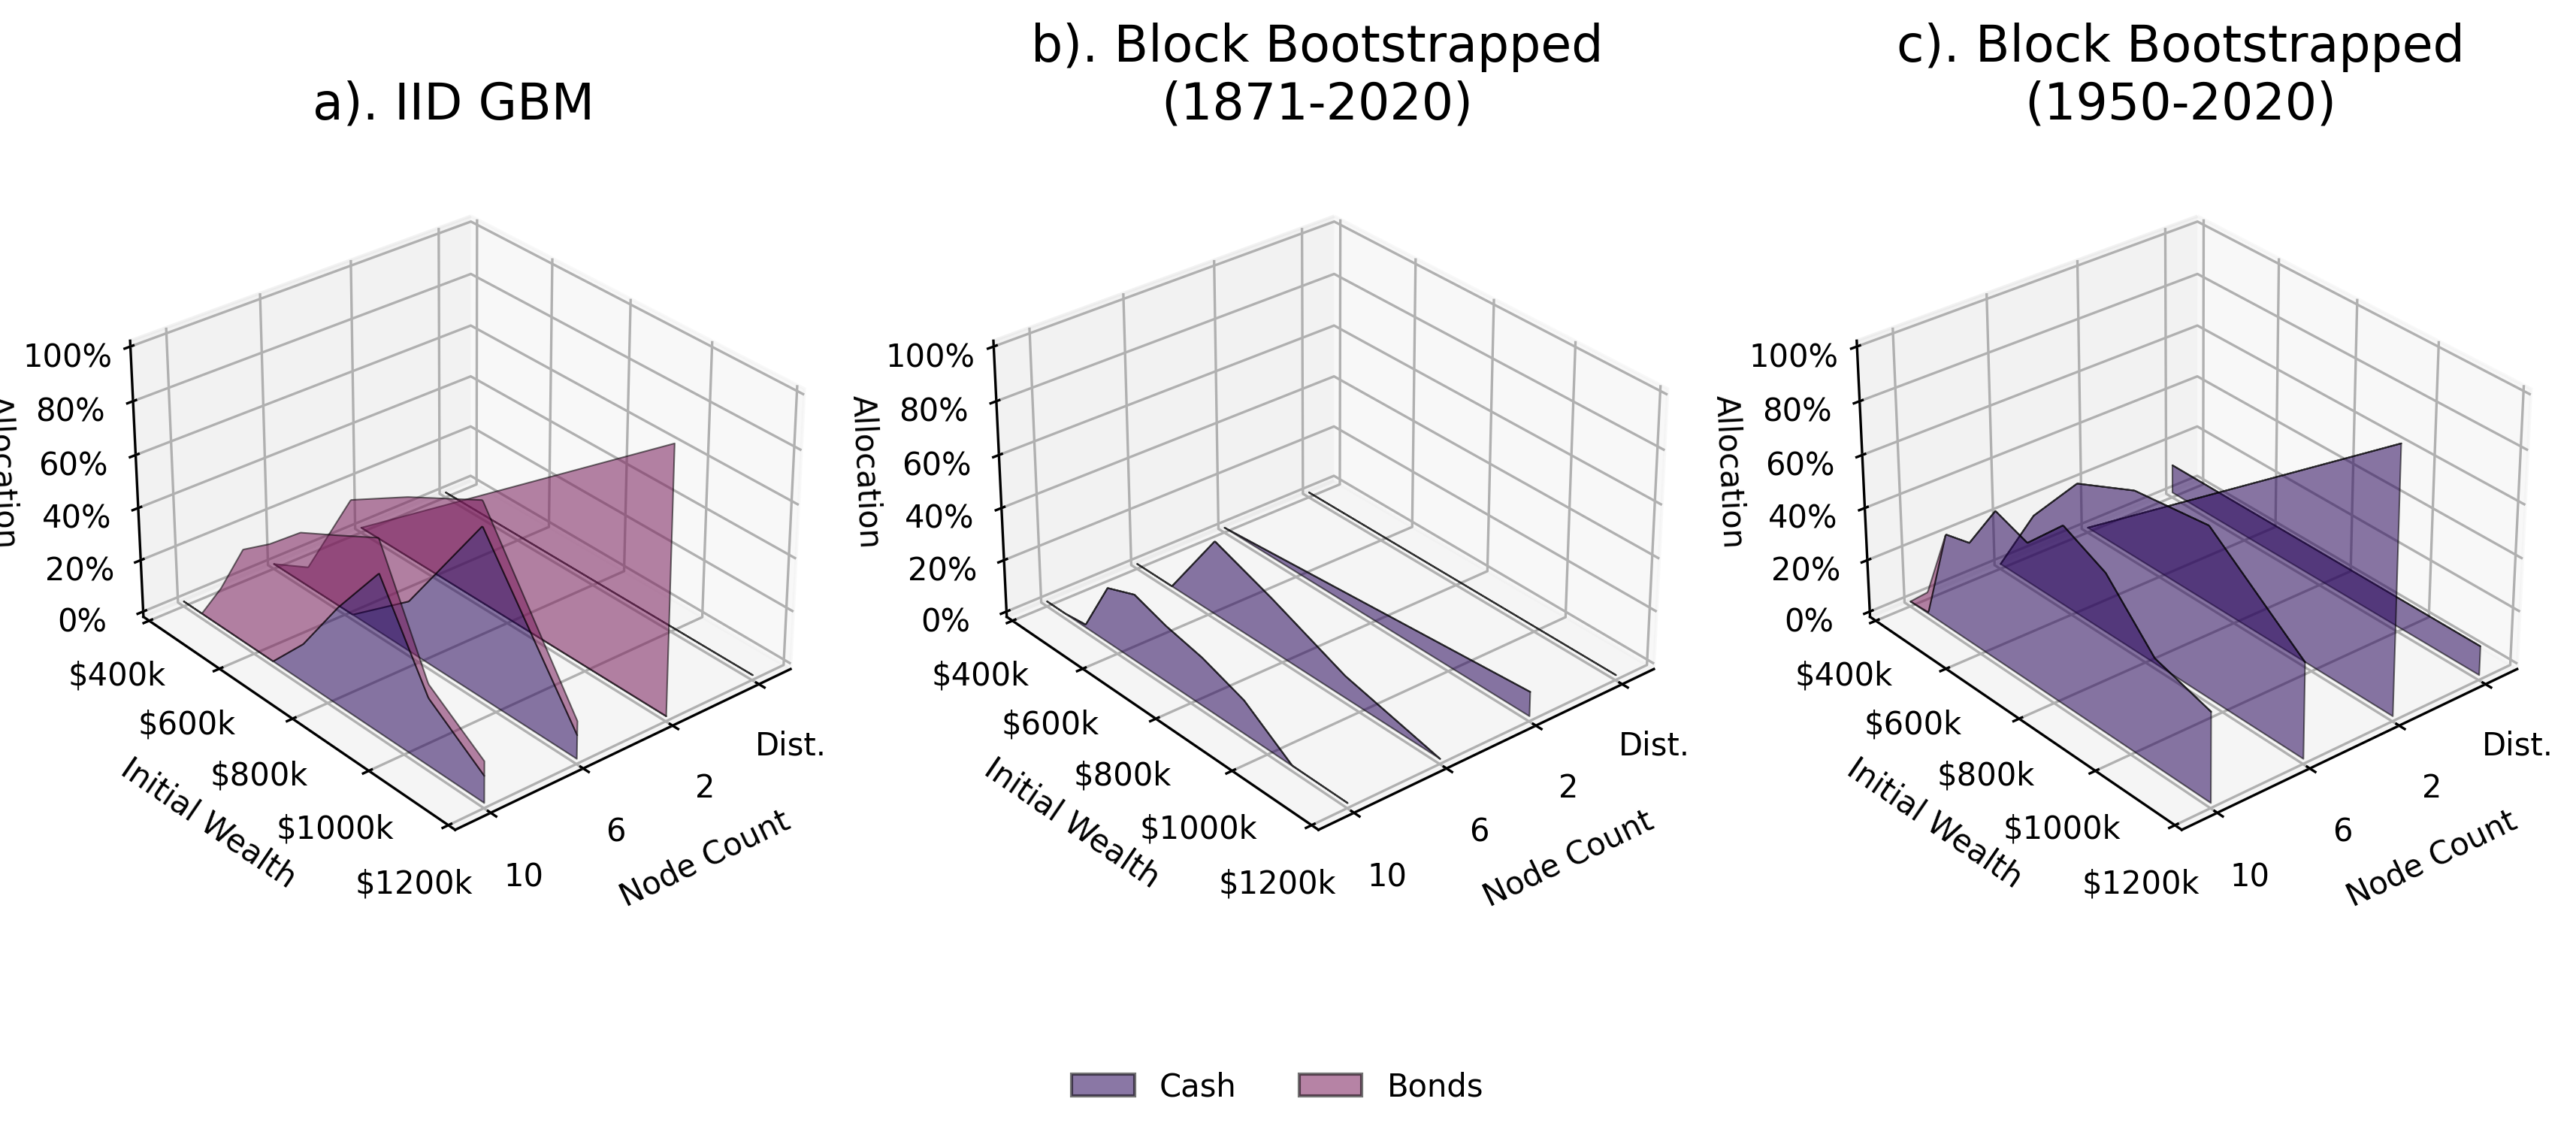

In [3]:
from matplotlib.collections import PolyCollection
from matplotlib.patches import Patch


N_TIME_NODES_FOR_3D = 1
WEALTH_NODE_COUNTS_TO_PLOT = [1, 2, 6, 10]

# Equal horizontal spacing: distributed baseline at -4, then 2/6/10 nodes at 0/4/8.
NODE_PLOT_POSITIONS = {1: -4.0, 2: 0.0, 6: 4.0, 10: 8.0}
NODE_PLOT_LABELS = {1: 'Dist.', 2: '2', 6: '6', 10: '10'}

# Use full wealth range for allocation surfaces.
WEALTH_SURFACE_MIN = 400_000
WEALTH_SURFACE_MAX = 1_200_000
WEALTH_SURFACE_X = np.linspace(WEALTH_SURFACE_MIN, WEALTH_SURFACE_MAX, 300)

policy_3d_data = best_policy_df.join(
    experiment_df,
    on='experiment_file',
).filter(
    (pl.col('n_time_nodes') == N_TIME_NODES_FOR_3D)
    & (pl.col('n_wealth_nodes').is_in(WEALTH_NODE_COUNTS_TO_PLOT))
    & (pl.col('initial_wealth').is_null())
)

fig = plt.figure(figsize=(14, 5.4), dpi=300)

asset_order = ['Cash', 'Bonds']
asset_colors = [colors['Cash'], colors['Bonds']]

for subplot_idx, sampler in enumerate(samplers_to_plot, start=1):
    ax = fig.add_subplot(1, 3, subplot_idx, projection='3d')
    ax.set_box_aspect((1.1, 1.25, 0.8))

    this_policy = policy_3d_data.filter(pl.col('sampler') == sampler)

    for node_count in WEALTH_NODE_COUNTS_TO_PLOT:
        if node_count == 1:
            node_policy = this_policy.filter(
                (pl.col('n_wealth_nodes') == 1) & (pl.col('initial_wealth').is_null())
            ).sort('wealth_node')
            if node_policy.height == 0:
                node_policy = this_policy.filter(pl.col('n_wealth_nodes') == 1).sort('wealth_node')
        else:
            node_policy = this_policy.filter(
                (pl.col('n_wealth_nodes') == node_count) & (pl.col('initial_wealth').is_null())
            ).sort('wealth_node')

        if node_policy.height == 0:
            continue

        if node_count == 1:
            cash_vals = np.full_like(WEALTH_SURFACE_X, float(node_policy['cash'][0]), dtype=float)
            bond_vals = np.full_like(WEALTH_SURFACE_X, float(node_policy['bonds'][0]), dtype=float)
        else:
            source_wealth = np.array(node_policy['wealth_node'].to_list(), dtype=float)
            cash_vals = np.interp(WEALTH_SURFACE_X, source_wealth, np.array(node_policy['cash'].to_list(), dtype=float))
            bond_vals = np.interp(WEALTH_SURFACE_X, source_wealth, np.array(node_policy['bonds'].to_list(), dtype=float))

        lower = np.zeros_like(WEALTH_SURFACE_X)
        stacked_series = [cash_vals, bond_vals]

        for asset_name, asset_color, values in zip(asset_order, asset_colors, stacked_series):
            upper = lower + values
            verts = list(zip(WEALTH_SURFACE_X, upper)) + list(zip(WEALTH_SURFACE_X[::-1], lower[::-1]))
            poly = PolyCollection(
                [verts],
                facecolors=asset_color,
                edgecolors='black',
                linewidths=0.5,
                alpha=0.55,
            )
            ax.add_collection3d(poly, zs=NODE_PLOT_POSITIONS[node_count], zdir='x')
            lower = upper

    x_tick_positions = [NODE_PLOT_POSITIONS[n] for n in WEALTH_NODE_COUNTS_TO_PLOT]
    x_tick_labels = [NODE_PLOT_LABELS[n] for n in WEALTH_NODE_COUNTS_TO_PLOT]

    plot_letter = get_plot_letter(0, subplot_idx - 1)
    plot_title = f'{plot_letter} {RETURN_SAMPLER_DISPLAY_NAMES[sampler]}'
    ax.set_title(plot_title, fontsize=16, pad=12)
    ax.set_xlim(min(x_tick_positions) - 1.2, max(x_tick_positions) + 1.2)
    ax.set_ylim(WEALTH_SURFACE_MIN, WEALTH_SURFACE_MAX)
    ax.set_zlim(0.0, 1.0)

    ax.set_xlabel('Node Count', labelpad=6)
    ax.set_ylabel('Initial Wealth', labelpad=8)
    ax.set_zlabel('Allocation', labelpad=4)

    ax.set_xticks(x_tick_positions)
    ax.set_xticklabels(x_tick_labels)

    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${int(y/1000)}k'))
    ax.zaxis.set_major_formatter(plt.FuncFormatter(lambda z, _: f'{z:.0%}'))

    ax.view_init(elev=30, azim=50)

legend_handles = [
    Patch(facecolor=colors[name], edgecolor='black', alpha=0.55, label=name)
    for name in asset_order
]
fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.01),
    ncol=2,
    frameon=False,
)

fig.tight_layout()
plt.savefig('./Plots/Wealth_Based_Policy_3D_Node_vs_Wealth.png', dpi=400, bbox_inches='tight', pad_inches=0.2)
plt.show()

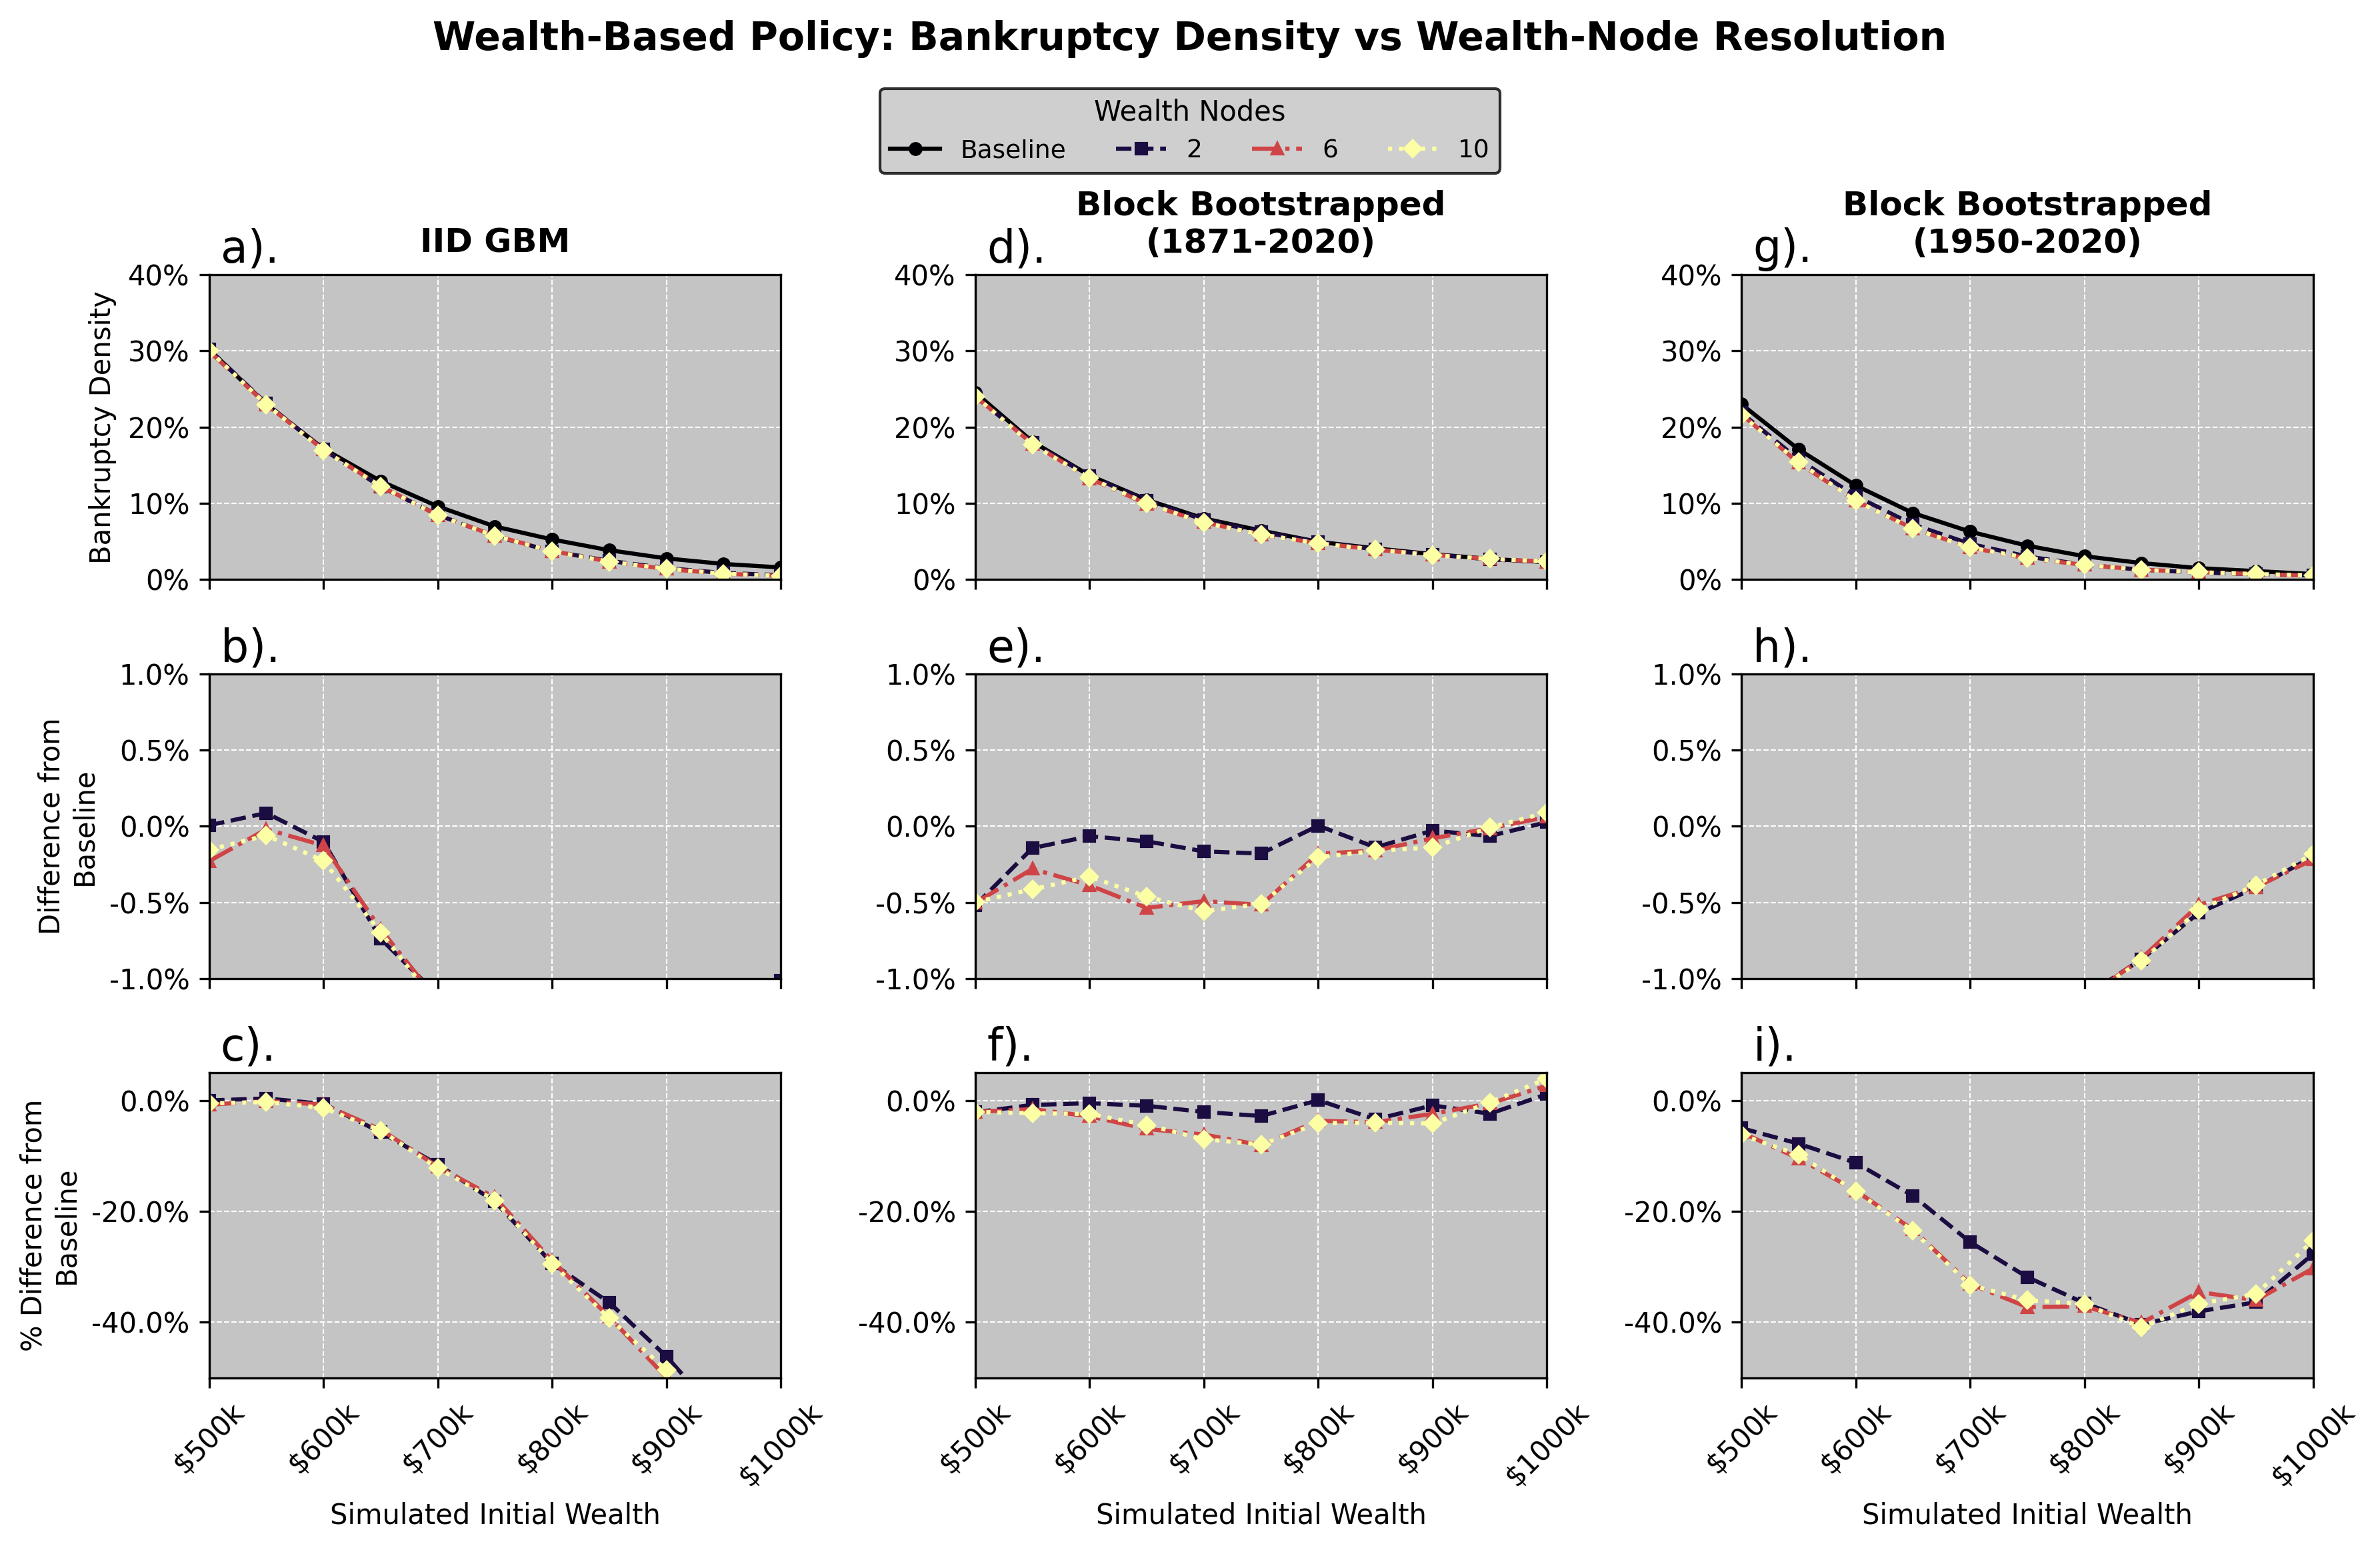

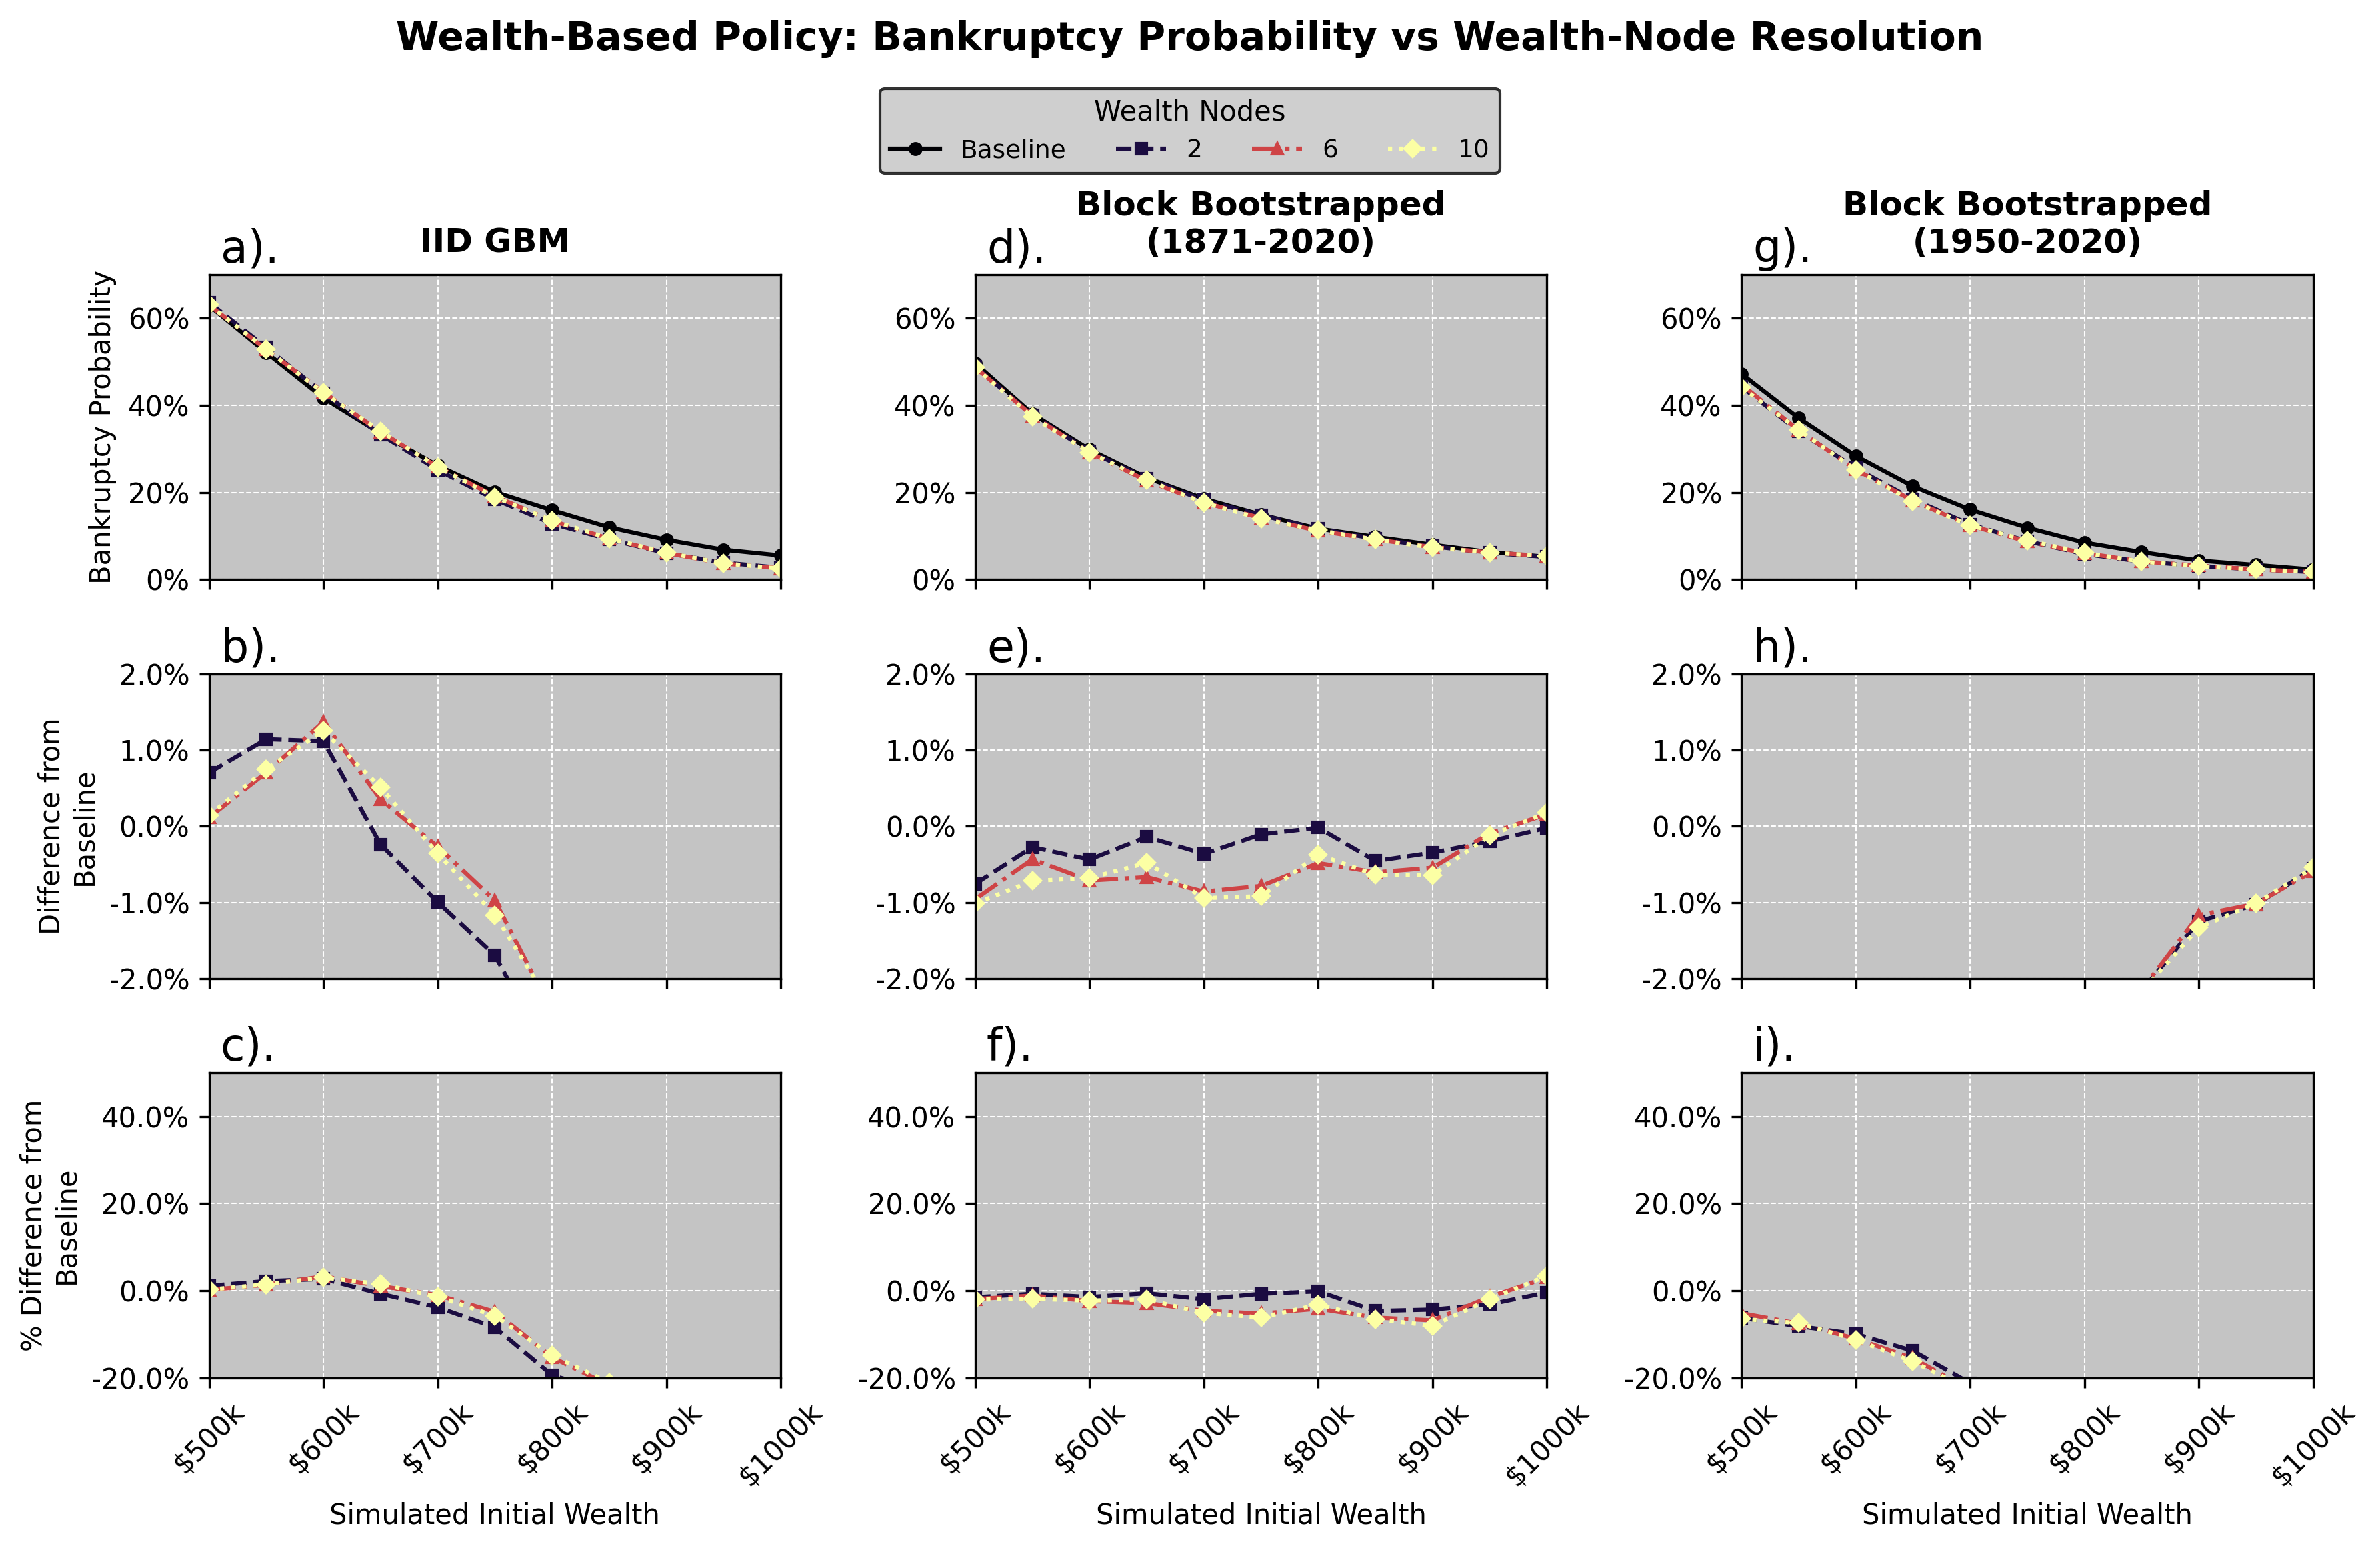

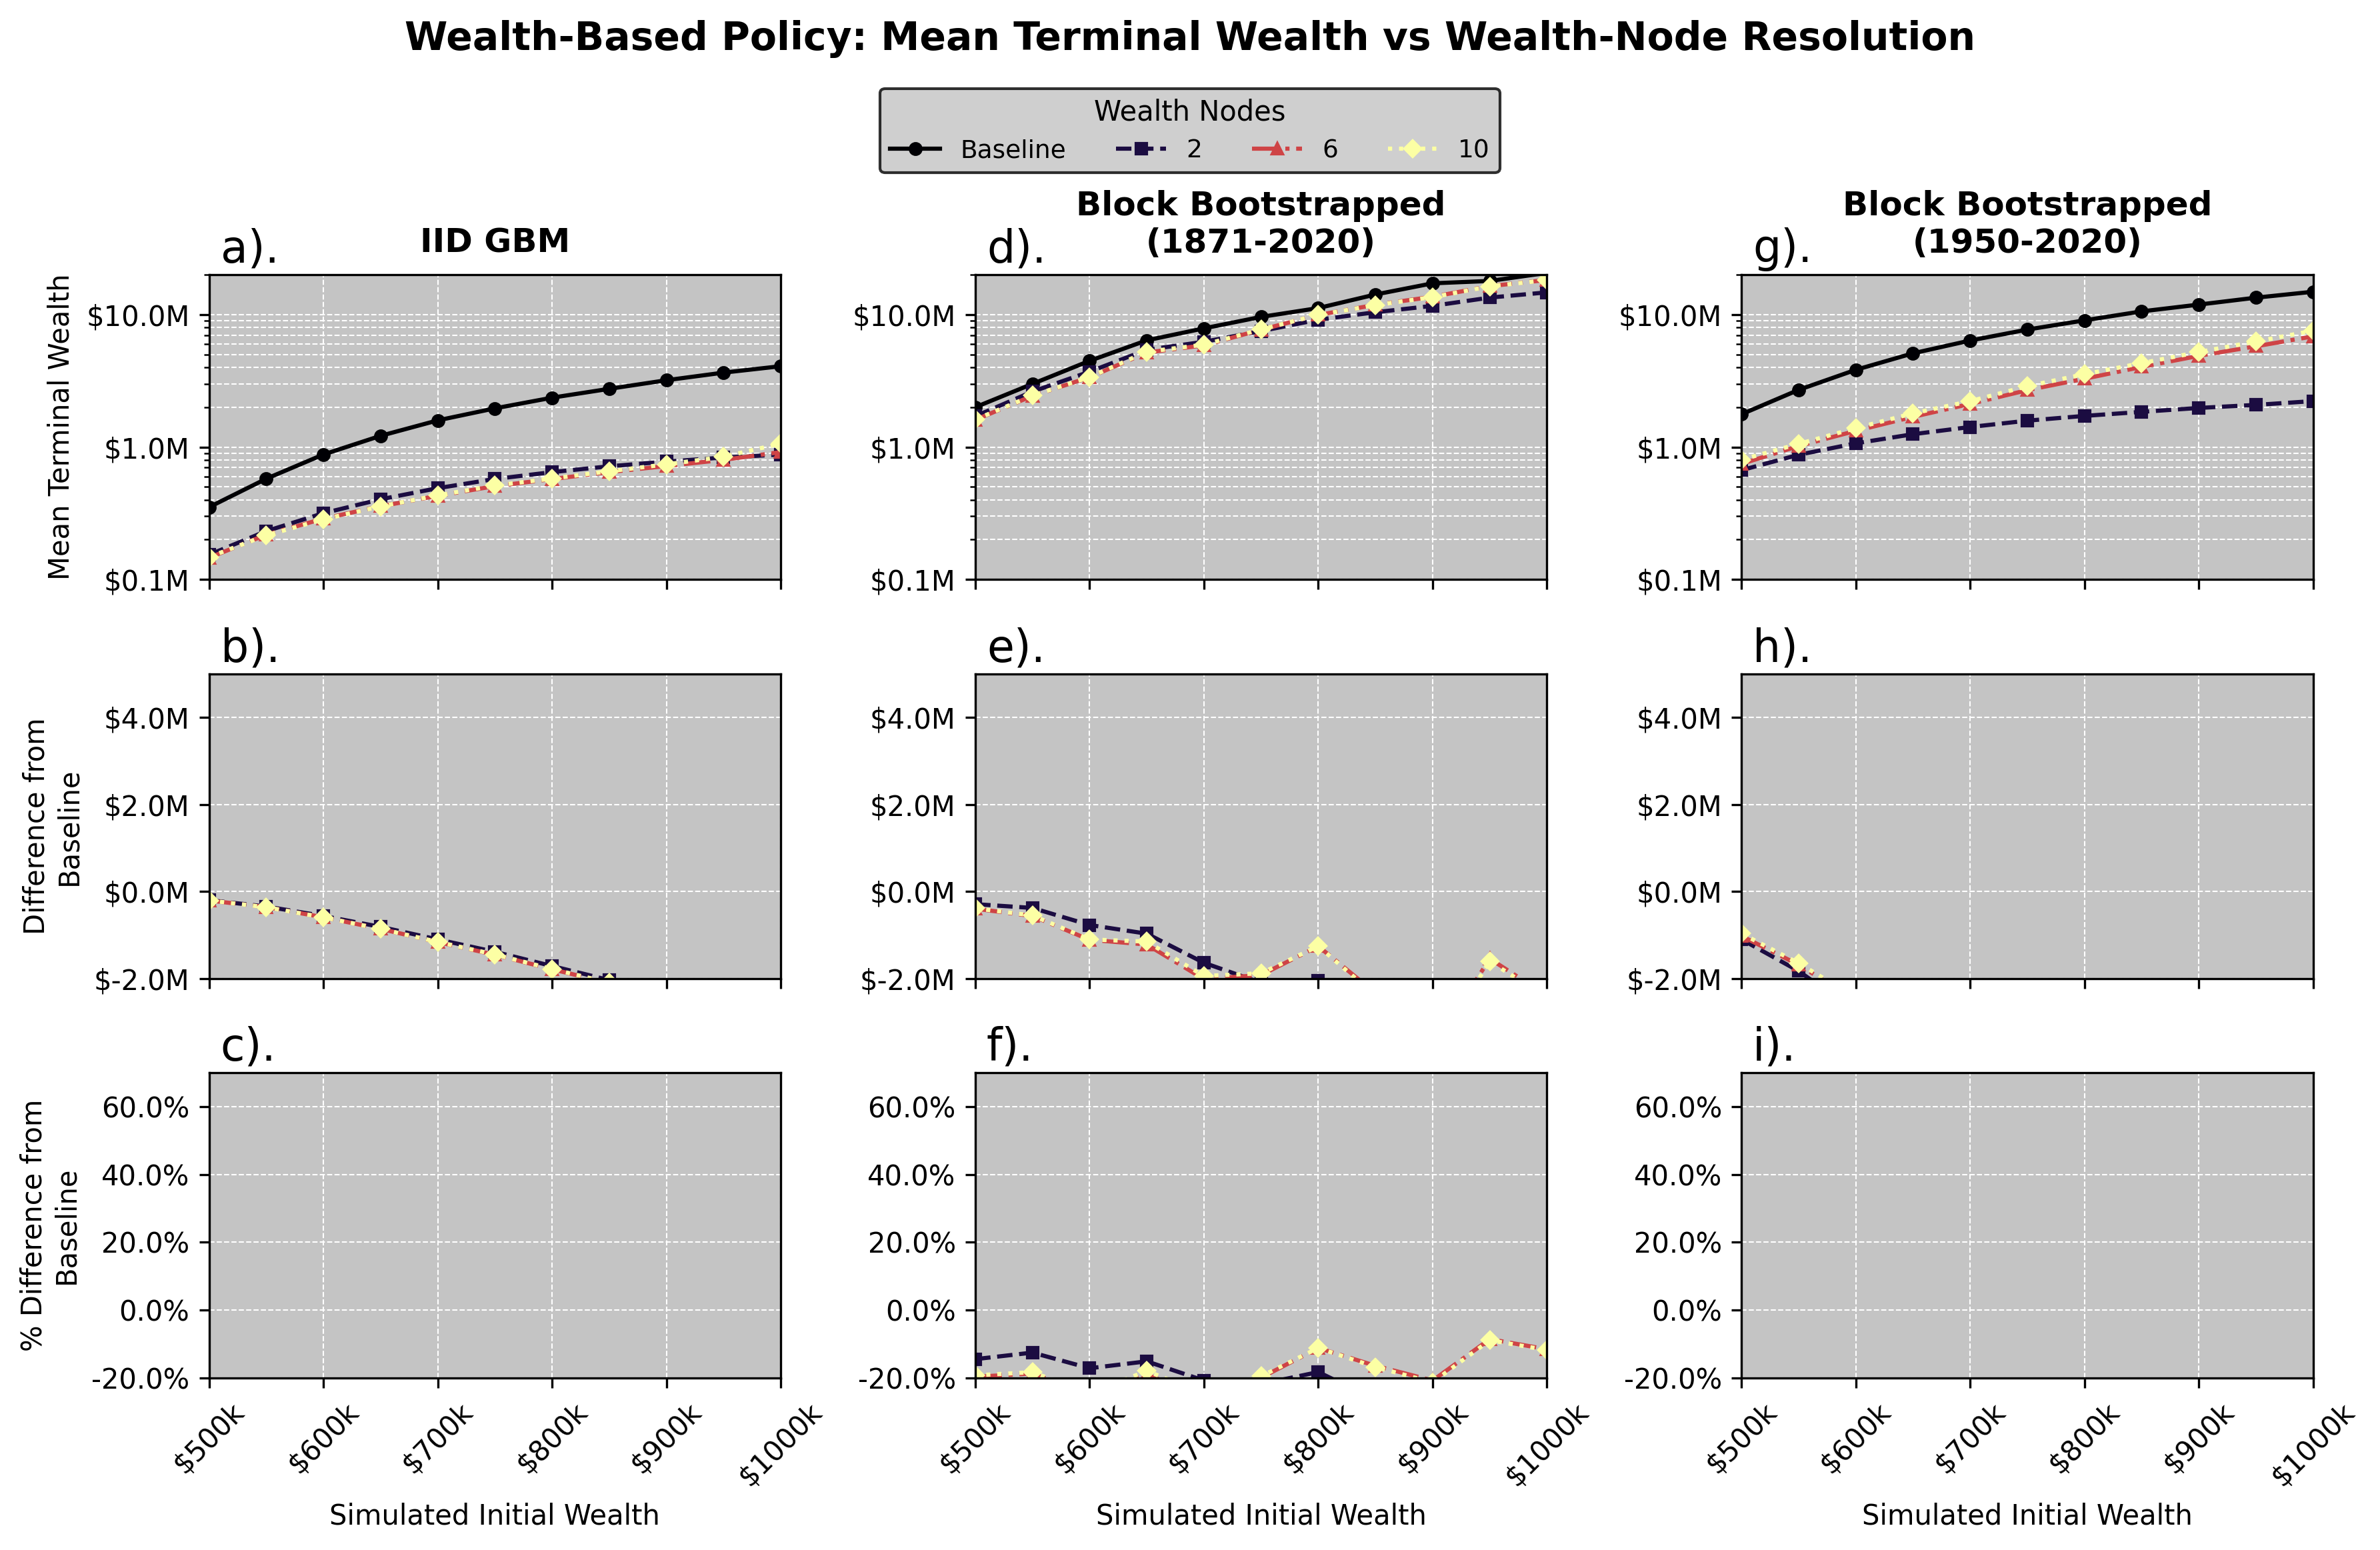

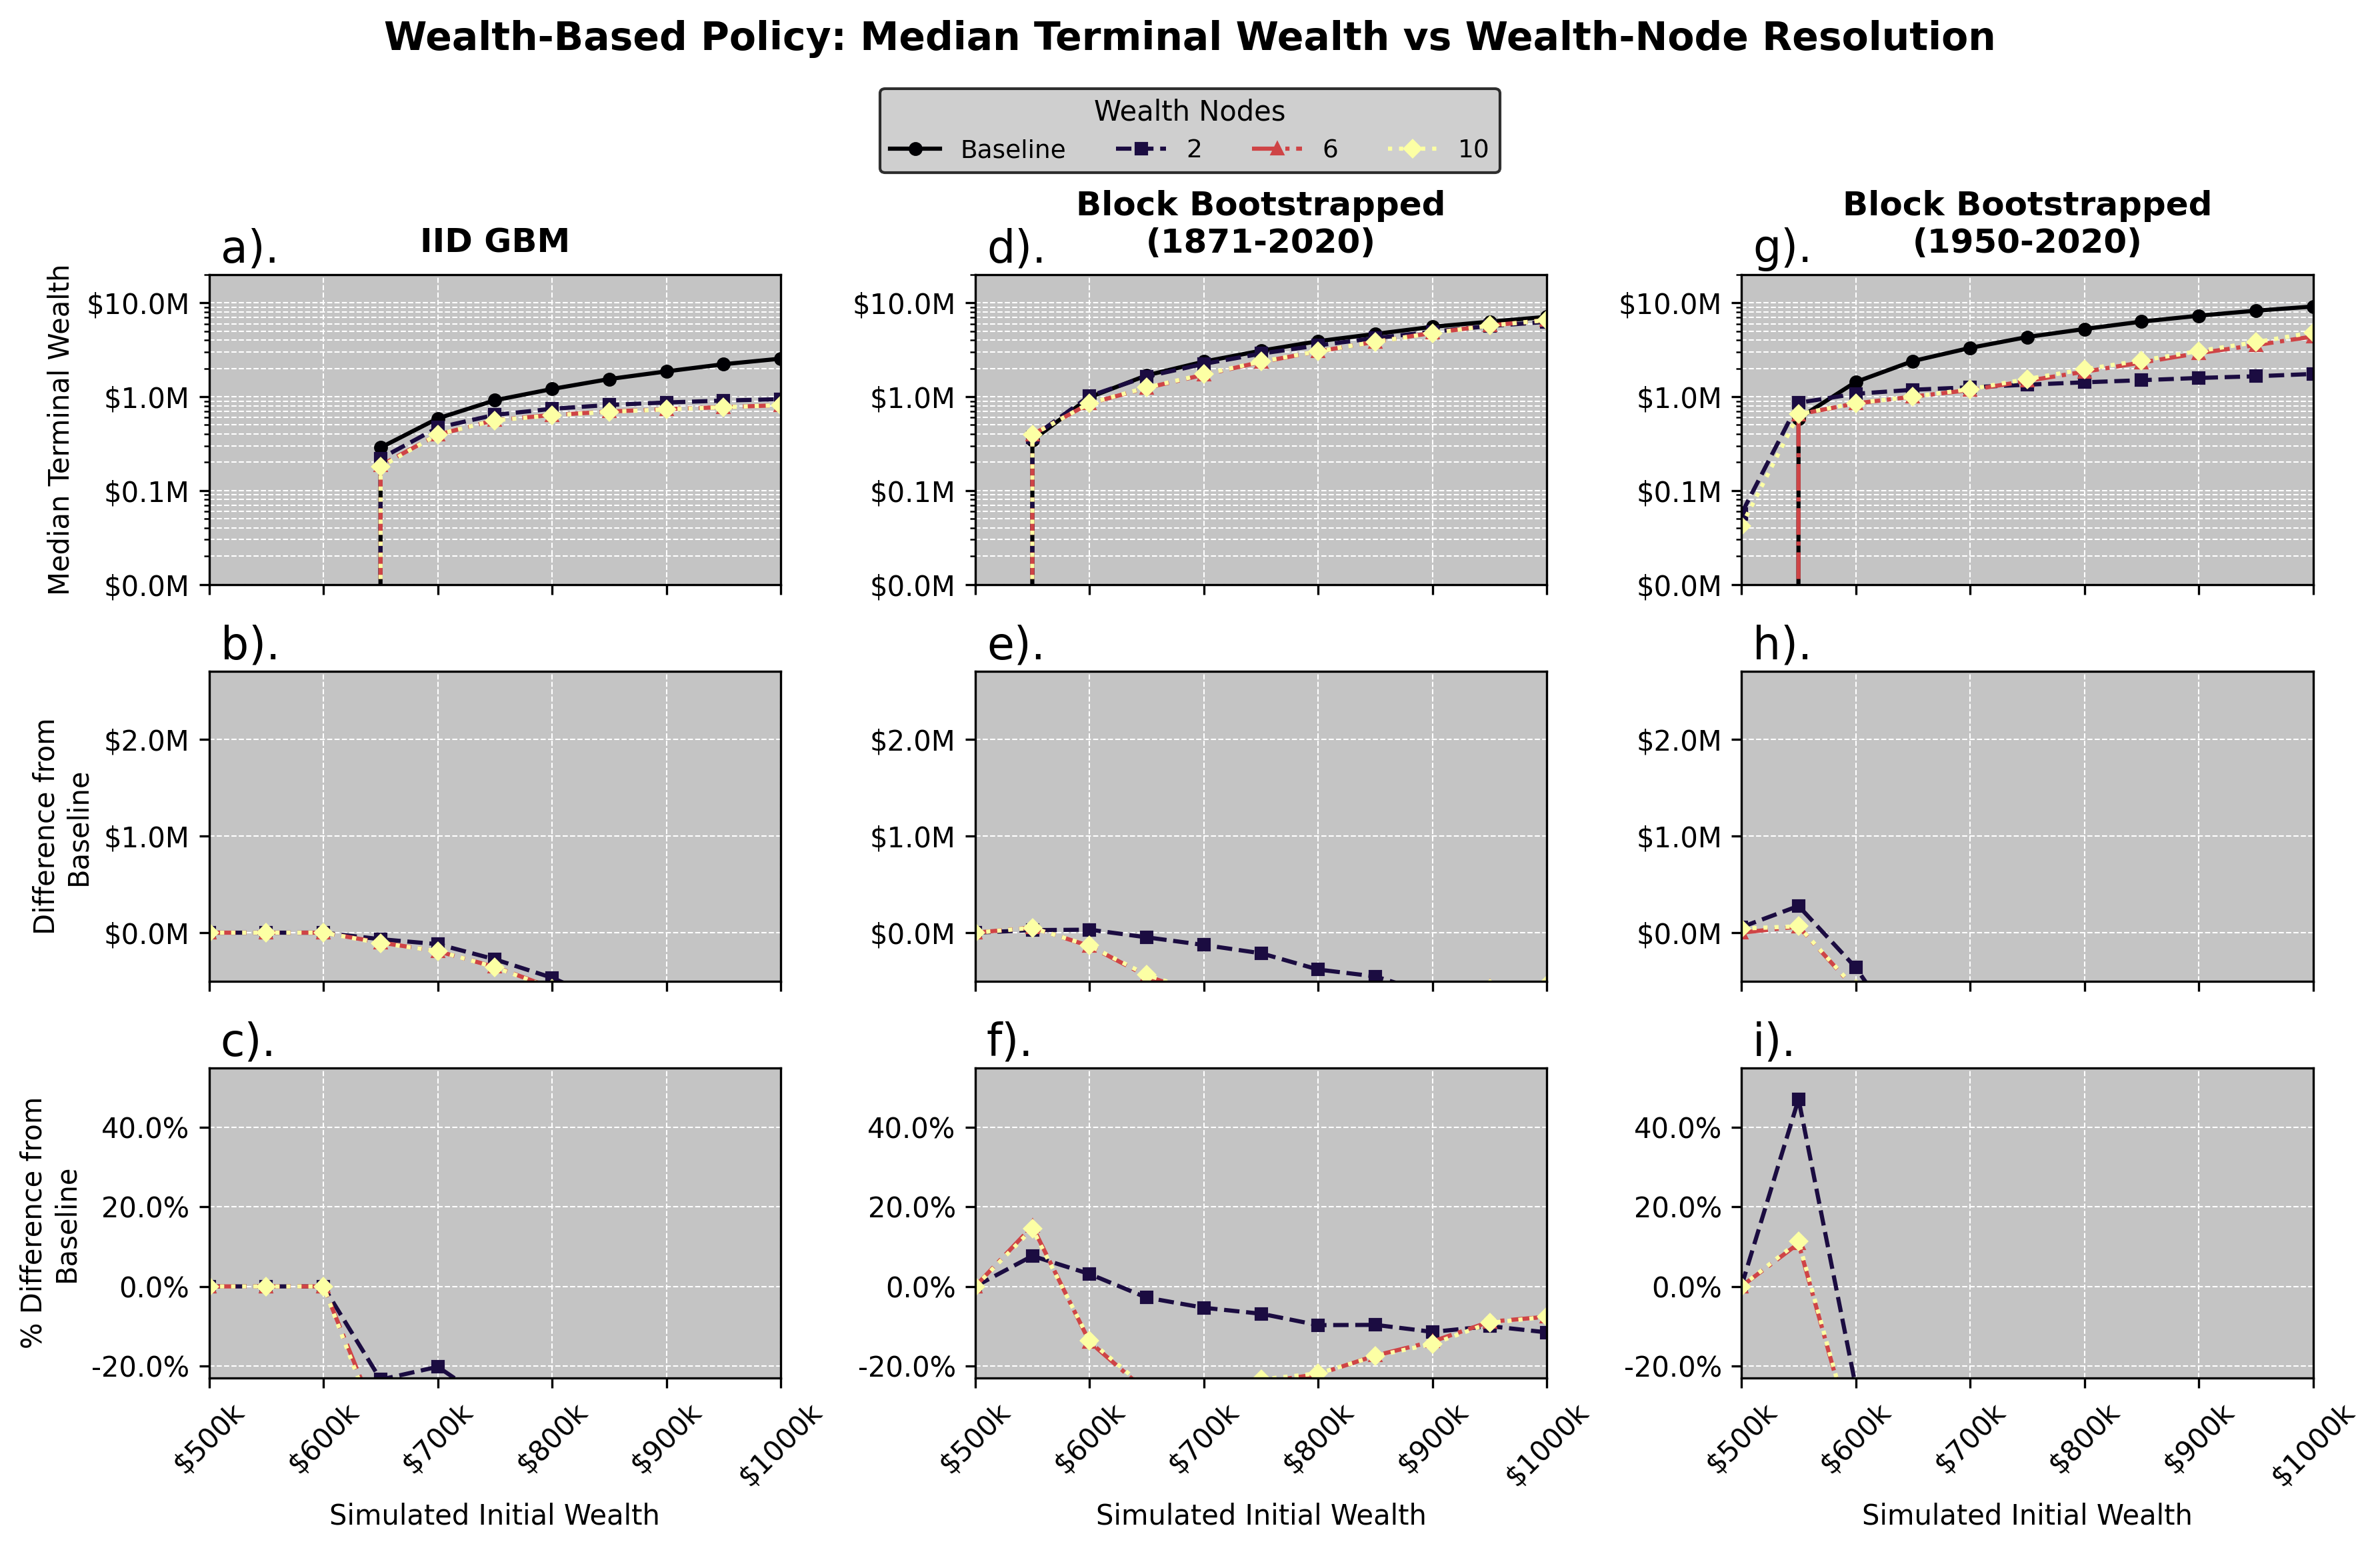

In [4]:
def get_plot_letter(row_idx: int, col_idx: int, samplers_to_plot: list) -> str:
    letter = chr(ord('a') + row_idx * len(samplers_to_plot) + col_idx)
    return f'{letter}).'


def _wealth_bucket_key(x: np.ndarray, bucket: float = 50_000.0) -> np.ndarray:
    return np.round(x / bucket).astype(int)


def plot_metric_vs_wealth_node_baseline(
    outcome_data: pl.DataFrame,
    nodes_to_plot: list[int],
    samplers_to_plot: list[str],
    metric: str = 'bankruptcy_density',
    baseline_node_count: int = 1,
    metric_label: str | None = None,
    diff_label: str = 'Difference from Baseline',
    rel_diff_label: str = 'Relative Difference from Baseline',
    top_ylim: tuple[float, float] | None = None,
    diff_ylim: tuple[float, float] | None = None,
    rel_diff_ylim: tuple[float, float] | None = None,
    top_as_percent: bool = True,
    diff_as_percent: bool = True,
    rel_diff_as_percent: bool = True,
) -> tuple[plt.Figure, np.ndarray]:
    fig, axes = plt.subplots(
        3,
        len(samplers_to_plot),
        figsize=(12, 7),
        dpi=300,
        squeeze=True,
        sharex=True,
    )

    linestyles = [None, '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 1))]
    markers = ['o', 's', '^', 'D', 'v', '*']

    if len(samplers_to_plot) == 1:
        axes = axes.reshape(3, 1)

    metric_label = metric_label or metric.replace('_', ' ').title()
    denom = max(nodes_to_plot) - min(nodes_to_plot)

    for j, sampler in enumerate(samplers_to_plot):
        ax1: plt.Axes = axes[0, j]
        ax2: plt.Axes = axes[1, j]
        ax3: plt.Axes = axes[2, j]

        sampler_data = outcome_data.filter(pl.col('sampler') == sampler)

        def _select_node_subset(node_count: int) -> pl.DataFrame:
            node_all = sampler_data.filter(pl.col('n_wealth_nodes') == node_count).sort('simulated_initial_wealth')
            if node_all.height == 0:
                return node_all
            node_distributed = node_all.filter(pl.col('initial_wealth').is_null())
            if node_distributed.height > 0:
                return node_distributed
            return node_all

        baseline_data = _select_node_subset(baseline_node_count)

        baseline_x = np.asarray(baseline_data['simulated_initial_wealth'].to_list(), dtype=float)
        baseline_y = np.asarray(baseline_data[metric].to_list(), dtype=float)

        baseline_mask = np.isfinite(baseline_x) & np.isfinite(baseline_y)
        baseline_x = baseline_x[baseline_mask]
        baseline_y = baseline_y[baseline_mask]
        baseline_key = _wealth_bucket_key(baseline_x)

        sampler_common_x = []

        for n in nodes_to_plot:
            this_data = _select_node_subset(n)

            x = np.asarray(this_data['simulated_initial_wealth'].to_list(), dtype=float)
            y = np.asarray(this_data[metric].to_list(), dtype=float)

            mask = np.isfinite(x) & np.isfinite(y)
            x = x[mask]
            y = y[mask]
            x_key = _wealth_bucket_key(x)

            common_key, base_idx, this_idx = np.intersect1d(baseline_key, x_key, return_indices=True)
            if common_key.size == 0:
                print(
                    f"Warning: no overlapping simulated_initial_wealth buckets for sampler '{sampler}' and n_wealth_nodes {n}. Skipping."
                )
                continue

            common_x = baseline_x[base_idx]
            baseline_y_aligned = baseline_y[base_idx]
            y_aligned = y[this_idx]

            diff_abs = y_aligned - baseline_y_aligned
            diff_rel = np.divide(
                y_aligned,
                baseline_y_aligned,
                out=np.full_like(y_aligned, 1, dtype=float),
                where=baseline_y_aligned != 0,
            ) - 1.0

            c = plt.cm.inferno(0.5 if denom == 0 else (n - min(nodes_to_plot)) / denom)
            linestyle = linestyles[nodes_to_plot.index(n) % len(linestyles)]
            marker = markers[nodes_to_plot.index(n) % len(markers)]
            node_label = 'Baseline' if n == baseline_node_count else f'{n}'

            ax1.plot(
                common_x,
                y_aligned,
                marker=marker,
                markersize=4,
                label=node_label,
                color=c,
                linestyle=linestyle,
            )

            sampler_common_x.append(common_x)

            if n == baseline_node_count:
                continue

            ax2.plot(
                common_x,
                diff_abs,
                marker=marker,
                markersize=4,
                label=f"{n}",
                color=c,
                linestyle=linestyle,
            )

            ax3.plot(
                common_x,
                diff_rel,
                marker=marker,
                markersize=4,
                label=f"{n}",
                color=c,
                linestyle=linestyle,
            )

        if sampler_common_x:
            x_joined = np.concatenate(sampler_common_x)
            x_min = float(np.nanmin(x_joined))
            x_max = float(np.nanmax(x_joined))
        else:
            fallback_x = np.asarray(
                sampler_data['simulated_initial_wealth'].to_list(),
                dtype=float,
            )
            fallback_x = fallback_x[np.isfinite(fallback_x)]
            if fallback_x.size > 0:
                x_min = float(np.nanmin(fallback_x))
                x_max = float(np.nanmax(fallback_x))
            else:
                x_min, x_max = 0.0, 1.0

        ax1.set_xlim(x_min, x_max)
        ax2.set_xlim(x_min, x_max)
        ax3.set_xlim(x_min, x_max)

        ax1.text(0.02, 1.01, get_plot_letter(j, 0, samplers_to_plot), transform=ax1.transAxes, fontsize=16, va='bottom', ha='left')
        ax2.text(0.02, 1.01, get_plot_letter(j, 1, samplers_to_plot), transform=ax2.transAxes, fontsize=16, va='bottom', ha='left')
        ax3.text(0.02, 1.01, get_plot_letter(j, 2, samplers_to_plot), transform=ax3.transAxes, fontsize=16, va='bottom', ha='left')

        if top_ylim is not None:
            ax1.set_ylim(*top_ylim)
        if diff_ylim is not None:
            ax2.set_ylim(*diff_ylim)
        if rel_diff_ylim is not None:
            ax3.set_ylim(*rel_diff_ylim)

        if top_as_percent:
            ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
        if diff_as_percent:
            ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
        if rel_diff_as_percent:
            ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))

        ax1.set_title(RETURN_SAMPLER_DISPLAY_NAMES[sampler], fontsize=12, fontweight='bold', pad=8)
        ax3.set_xlabel('Simulated Initial Wealth', fontsize=10)

    for plot in axes.flatten():
        plot.grid(True, which='both', linestyle='--', linewidth=0.5, color='white')
        plot.set_facecolor('#c4c4c4')

    axes[0, 0].set_ylabel(metric_label, fontsize=10)
    axes[1, 0].set_ylabel(diff_label, fontsize=10)
    axes[2, 0].set_ylabel(rel_diff_label, fontsize=10)

    def _safe_k_formatter(x: float, _: int) -> str:
        if not np.isfinite(x):
            return ''
        return f'${int(x/1000)}k'

    for j in range(len(samplers_to_plot)):
        axes[2, j].xaxis.set_major_formatter(plt.FuncFormatter(_safe_k_formatter))
        axes[2, j].tick_params(axis='x', rotation=45)

    fig.tight_layout()

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles=handles,
            labels=labels,
            loc='upper center',
            bbox_to_anchor=(0.5, 1.06),
            ncol=len(nodes_to_plot),
            fontsize=9,
            frameon=True,
            title='Wealth Nodes',
            title_fontsize=10,
            facecolor='#c4c4c4',
            edgecolor='black',
        )

    return fig, axes


outcome_node_compare = outcomes_df.join(
    experiment_df,
    on='experiment_file',
).filter(
    (pl.col('n_time_nodes') == 1)
    & (pl.col('n_wealth_nodes').is_in([1, 2, 6, 10]))
    & (pl.col('initial_wealth').is_null())
)

nodes_to_plot = [1, 2, 6, 10]

fig, axes = plot_metric_vs_wealth_node_baseline(
    outcome_data=outcome_node_compare,
    nodes_to_plot=nodes_to_plot,
    samplers_to_plot=samplers_to_plot,
    metric='bankruptcy_density',
    baseline_node_count=1,
    metric_label='Bankruptcy Density',
    diff_label='Difference from\nBaseline',
    rel_diff_label='% Difference from\nBaseline',
    top_ylim=(0, 0.4),
    diff_ylim=(-0.01, 0.01),
    rel_diff_ylim=(-0.5, 0.05),
    top_as_percent=True,
    diff_as_percent=True,
    rel_diff_as_percent=True,
)
plt.suptitle('Wealth-Based Policy: Bankruptcy Density vs Wealth-Node Resolution', fontsize=14, fontweight='bold', y=1.1)
plt.savefig('./Plots/Wealth_Based_Policy_Bankruptcy_Density_Comparison.png', dpi=400, bbox_inches='tight', pad_inches=0.2)

fig, axes = plot_metric_vs_wealth_node_baseline(
    outcome_data=outcome_node_compare,
    nodes_to_plot=nodes_to_plot,
    samplers_to_plot=samplers_to_plot,
    metric='bankruptcy_probability',
    baseline_node_count=1,
    metric_label='Bankruptcy Probability',
    diff_label='Difference from\nBaseline',
    rel_diff_label='% Difference from\nBaseline',
    top_ylim=(0, 0.7),
    diff_ylim=(-0.02, 0.02),
    rel_diff_ylim=(-0.2, 0.5),
    top_as_percent=True,
    diff_as_percent=True,
    rel_diff_as_percent=True,
)
plt.suptitle('Wealth-Based Policy: Bankruptcy Probability vs Wealth-Node Resolution', fontsize=14, fontweight='bold', y=1.1)
plt.savefig('./Plots/Wealth_Based_Policy_Bankruptcy_Probability_Comparison.png', dpi=400, bbox_inches='tight', pad_inches=0.2)

fig, axes = plot_metric_vs_wealth_node_baseline(
    outcome_data=outcome_node_compare,
    nodes_to_plot=nodes_to_plot,
    samplers_to_plot=samplers_to_plot,
    metric='mean_terminal_wealth',
    baseline_node_count=1,
    metric_label='Mean Terminal Wealth',
    diff_label='Difference from\nBaseline',
    rel_diff_label='% Difference from\nBaseline',
    top_ylim=(1e5, 2e7),
    diff_ylim=(-2e6, 5e6),
    rel_diff_ylim=(-0.2, 0.7),
    top_as_percent=False,
    diff_as_percent=False,
)
for j in range(len(samplers_to_plot)):
    axes[0, j].set_yscale('log')
currency_fmt = plt.FuncFormatter(lambda y, _: f'${y/1_000_000:.1f}M' if np.isfinite(y) else '')
for j in range(len(samplers_to_plot)):
    axes[0, j].yaxis.set_major_formatter(currency_fmt)
    axes[1, j].yaxis.set_major_formatter(currency_fmt)
plt.suptitle('Wealth-Based Policy: Mean Terminal Wealth vs Wealth-Node Resolution', fontsize=14, fontweight='bold', y=1.1)
plt.savefig('./Plots/Wealth_Based_Policy_Mean_Terminal_Wealth_Comparison.png', dpi=400, bbox_inches='tight', pad_inches=0.2)

fig, axes = plot_metric_vs_wealth_node_baseline(
    outcome_data=outcome_node_compare.with_columns(pl.col('median_terminal_wealth').cast(pl.Int64)),
    nodes_to_plot=nodes_to_plot,
    samplers_to_plot=samplers_to_plot,
    metric='median_terminal_wealth',
    baseline_node_count=1,
    metric_label='Median Terminal Wealth',
    diff_label='Difference from\nBaseline',
    rel_diff_label='% Difference from\nBaseline',
    top_ylim=(1e4, 2e7),
    diff_ylim=(-5e5, 2.7e6),
    rel_diff_ylim=(-0.23, 0.55),
    top_as_percent=False,
    diff_as_percent=False,
)
for j in range(len(samplers_to_plot)):
    axes[0, j].set_yscale('log')
for j in range(len(samplers_to_plot)):
    axes[0, j].yaxis.set_major_formatter(currency_fmt)
    axes[1, j].yaxis.set_major_formatter(currency_fmt)
plt.suptitle('Wealth-Based Policy: Median Terminal Wealth vs Wealth-Node Resolution', fontsize=14, fontweight='bold', y=1.1)
plt.savefig('./Plots/Wealth_Based_Policy_Median_Terminal_Wealth_Comparison.png', dpi=400, bbox_inches='tight', pad_inches=0.2)

plt.show()

In [5]:
outcomes_df.join(
    experiment_df,
    on='experiment_file',
).filter(
    (pl.col('n_time_nodes') == 1)
    & (pl.col('n_wealth_nodes')==1)
    & (pl.col('initial_wealth').is_not_null())
)


experiment_file,simulated_initial_wealth,bankruptcy_probability,bankruptcy_density,mean_terminal_wealth,std_terminal_wealth,median_terminal_wealth,p05_terminal_wealth,p10_terminal_wealth,p25_terminal_wealth,p75_terminal_wealth,p90_terminal_wealth,p95_terminal_wealth,initial_wealth,n_time_nodes,n_wealth_nodes,sampler
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str
"""../Fixed Policy/Results\experi…",1e6,0.0517075,0.022573,2.0753e7,1.9196e8,7.1650e6,0.0,1.0328e6,3.1798e6,1.5685e7,3.3014e7,5.4544e7,1e6,1,1,"""block_bootstrapped"""
"""../Fixed Policy/Results\experi…",1e6,0.0175625,0.005382,6.8564e6,7.0600e6,4.8213e6,780764.478956,1.4125e6,2.6545e6,8.6027e6,1.4398e7,1.9527e7,1e6,1,1,"""block_bootstrapped_1950"""
"""../Fixed Policy/Results\experi…",1e6,0.0343175,0.004902,725524.384343,545952.937122,629679.548626,6.5787e-12,105366.767593,326460.522203,1.0126e6,1.4453e6,1.7561e6,1e6,1,1,"""cholesky"""
"""../Fixed Policy/Results\experi…",500000.0,0.489305,0.24108,2.1123e6,3.6332e7,2.7490e-12,0.0,0.0,0.0,1.3747e6,4.4679e6,7.9463e6,500000.0,1,1,"""block_bootstrapped"""
"""../Fixed Policy/Results\experi…",500000.0,0.450195,0.224903,2.6372e6,6.0122e6,9.3731e-11,0.0,0.0,0.0,2.8770e6,7.6937e6,1.2427e7,500000.0,1,1,"""block_bootstrapped_1950"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""../Fixed Policy/Results\experi…",900000.0,0.03636,0.011092,5.1391e6,5.6265e6,3.5323e6,49169.007224,705062.499467,1.7791e6,6.5434e6,1.1143e7,1.5249e7,900000.0,1,1,"""block_bootstrapped_1950"""
"""../Fixed Policy/Results\experi…",900000.0,0.078115,0.016266,945775.246884,915499.881045,725837.031251,0.0,5.0022e-12,273205.275604,1.3515e6,2.1188e6,2.7060e6,900000.0,1,1,"""cholesky"""
"""../Fixed Policy/Results\experi…",950000.0,0.063145,0.027003,1.8435e7,1.7194e8,6.3420e6,0.0,653866.610287,2.6982e6,1.4112e7,2.9811e7,4.9005e7,950000.0,1,1,"""block_bootstrapped"""


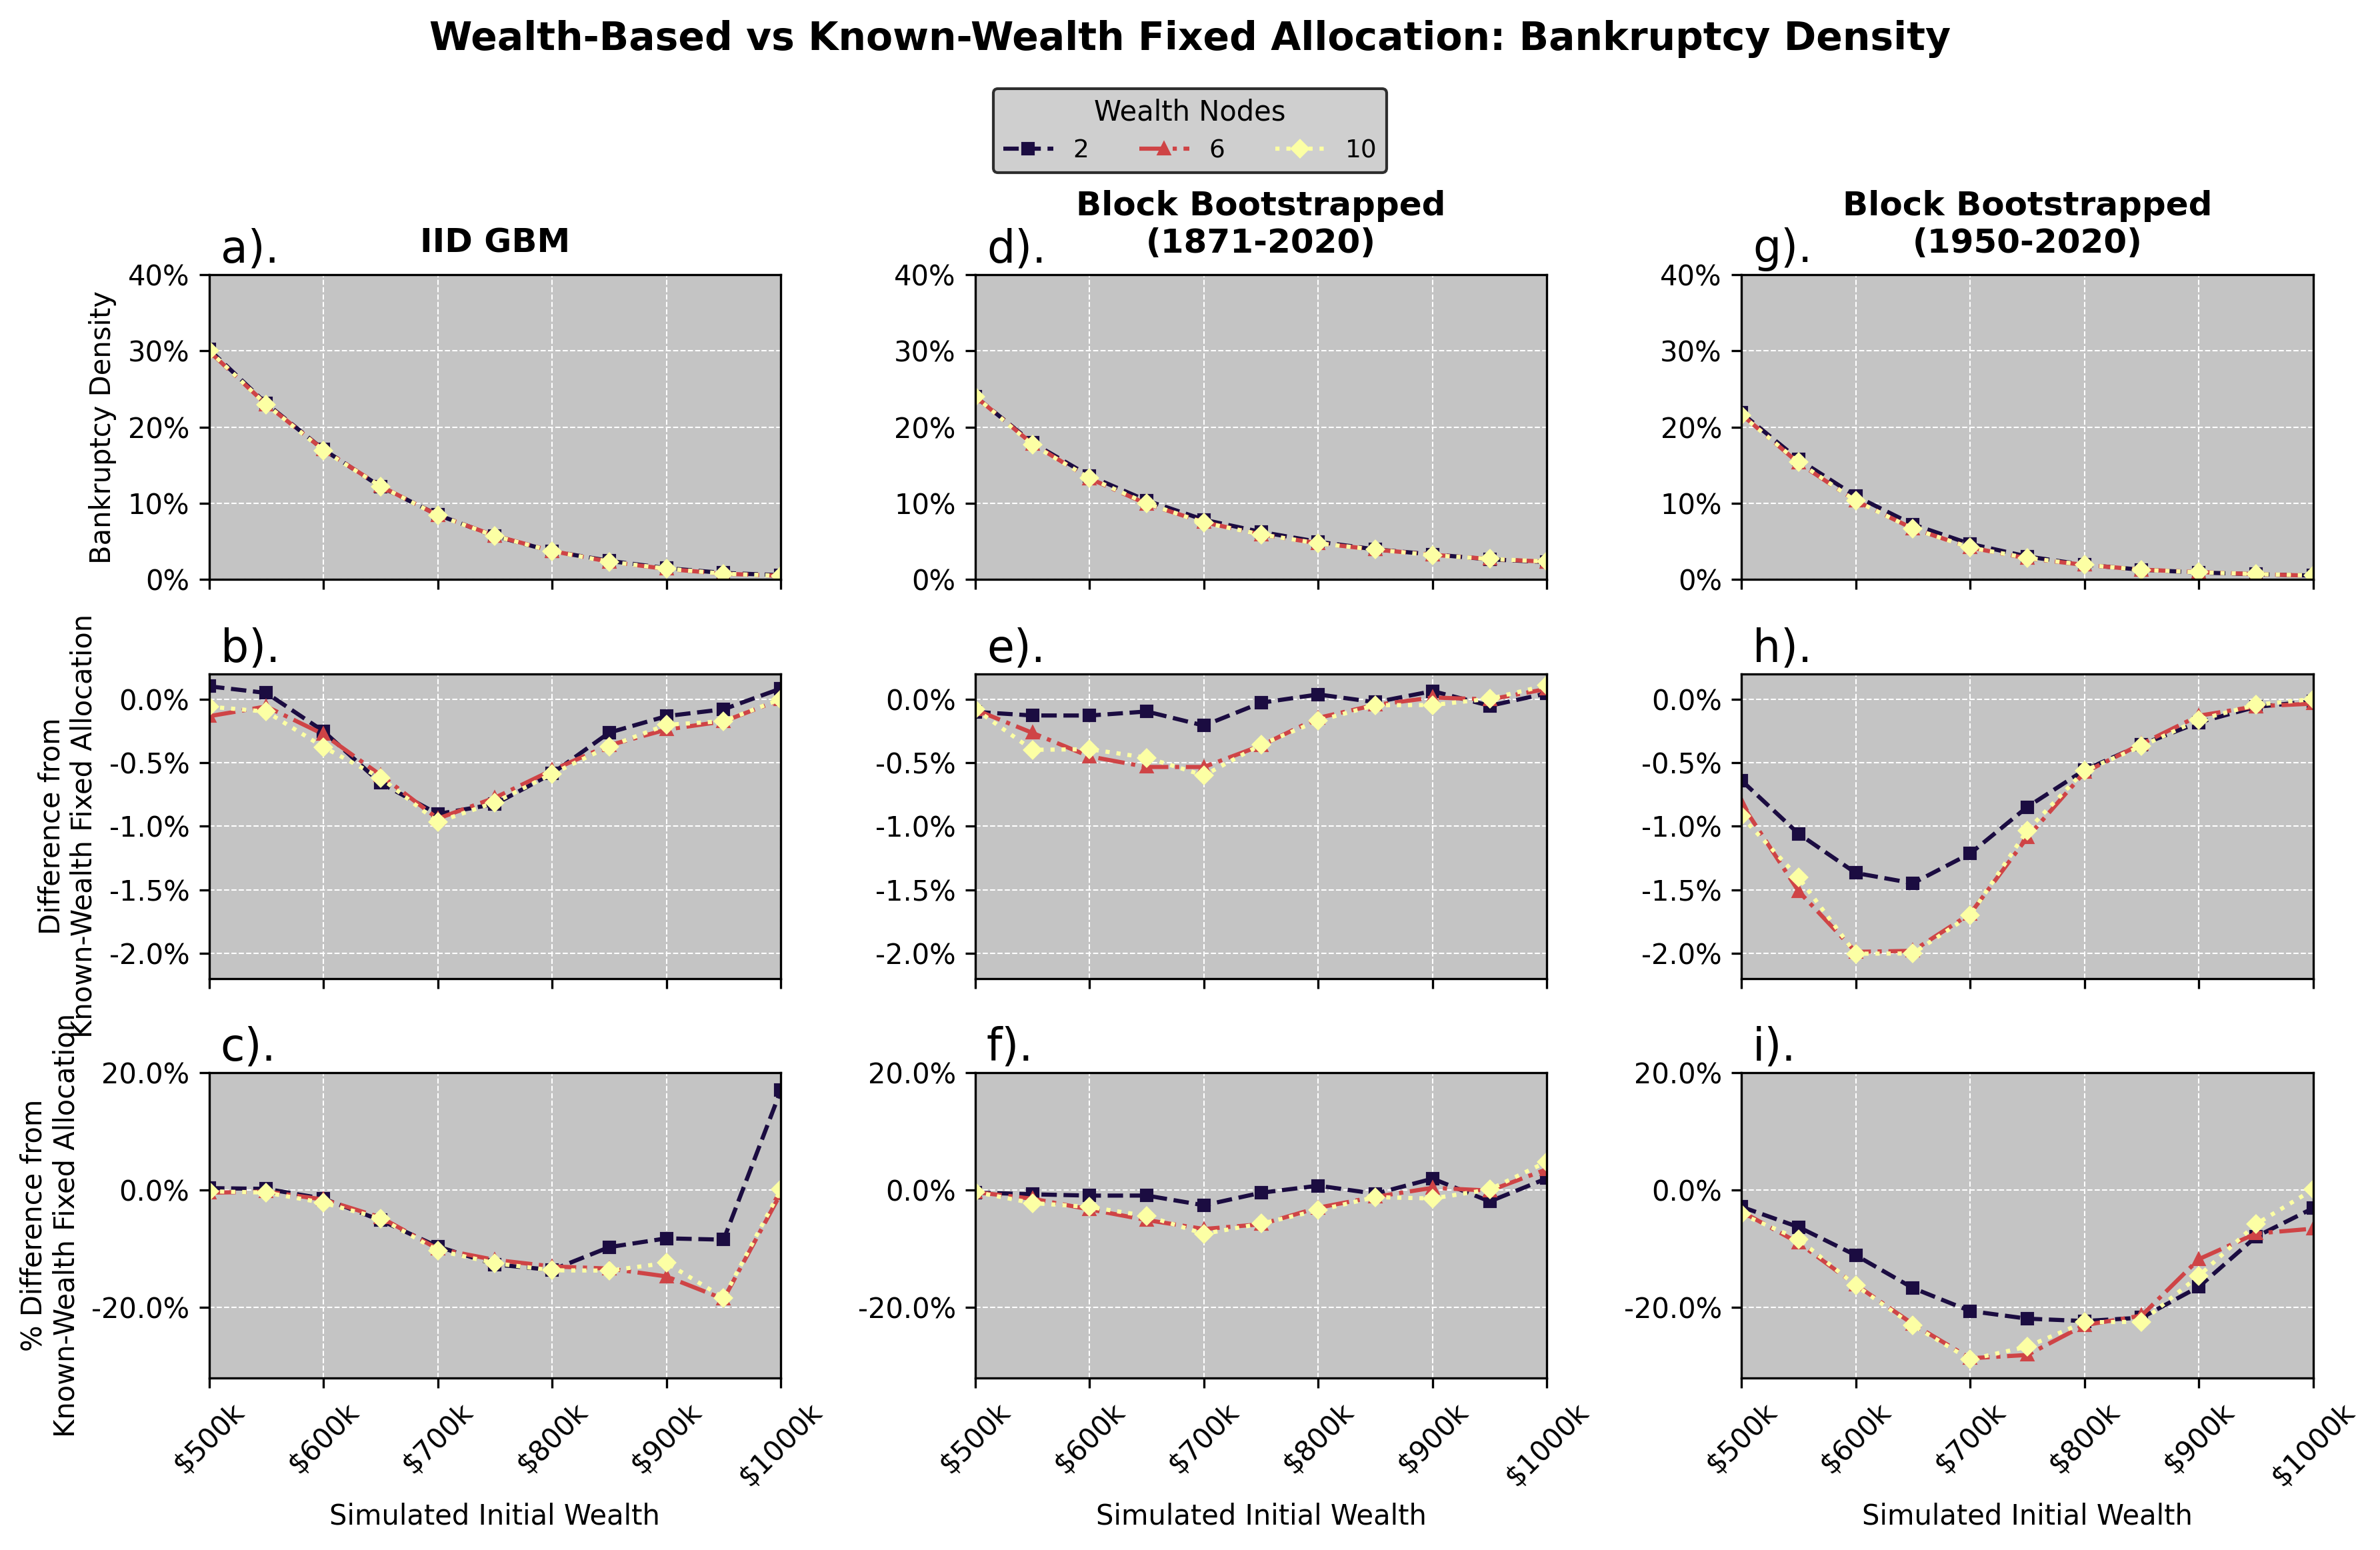

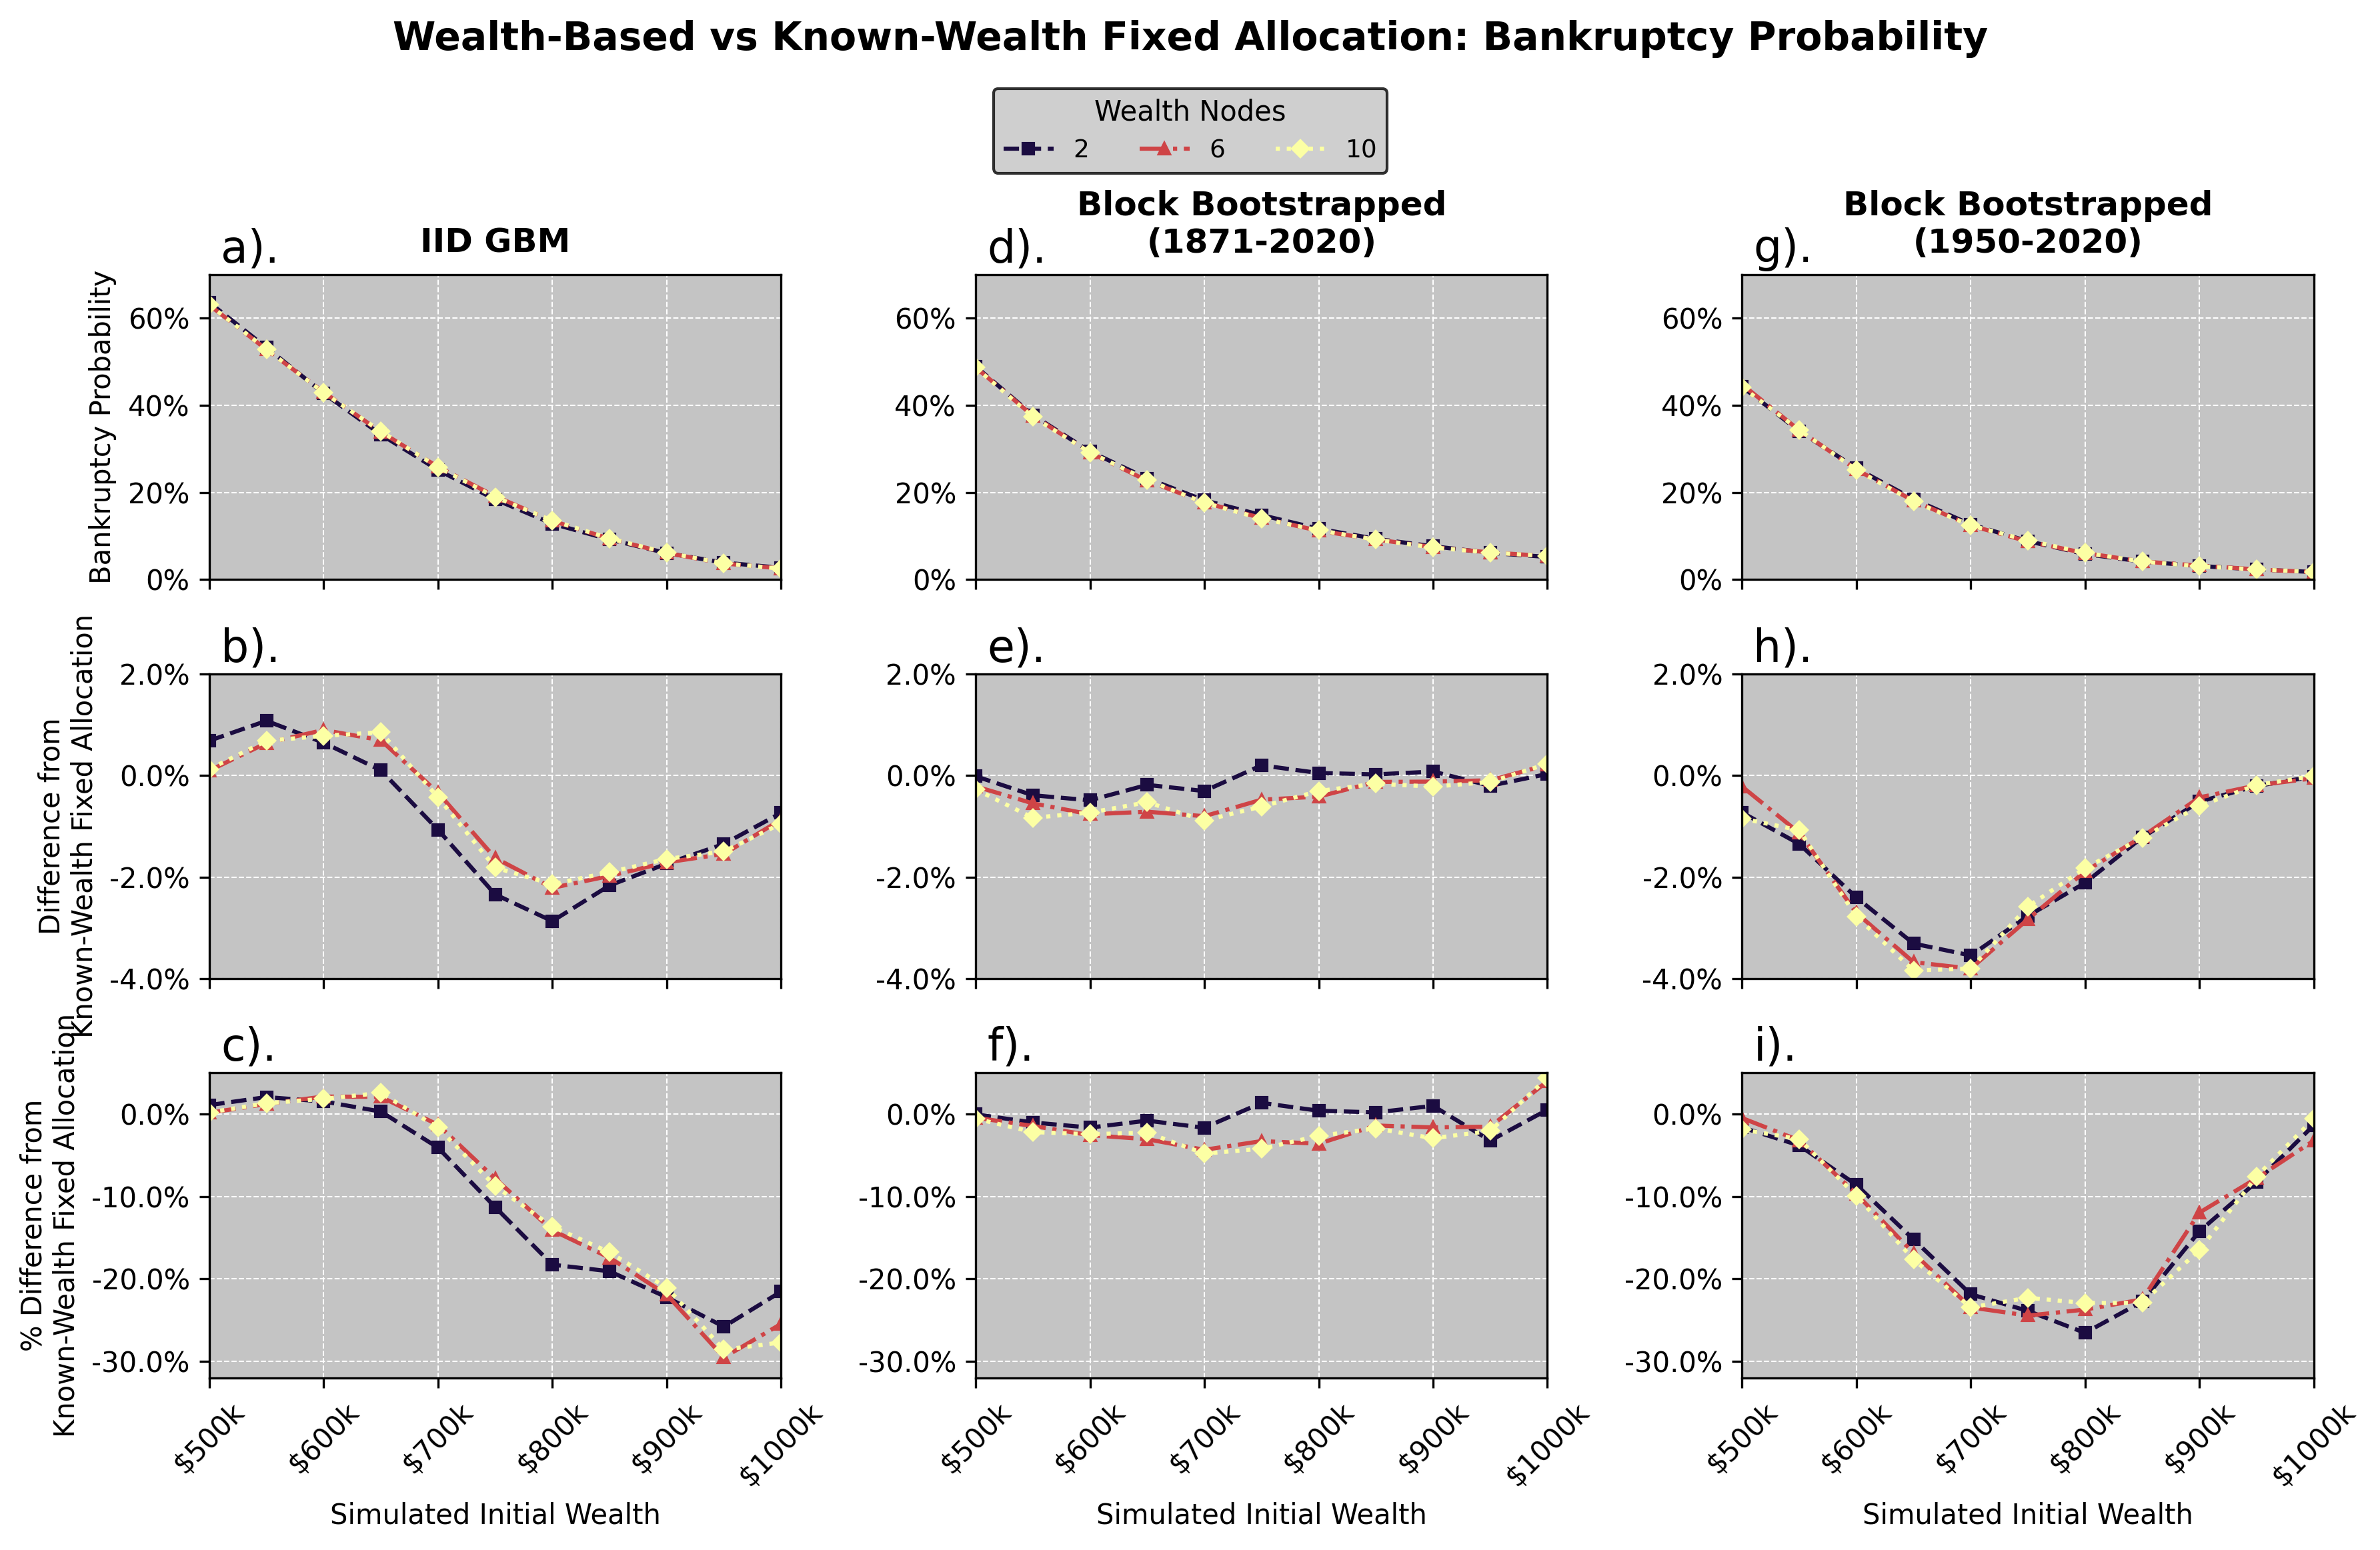

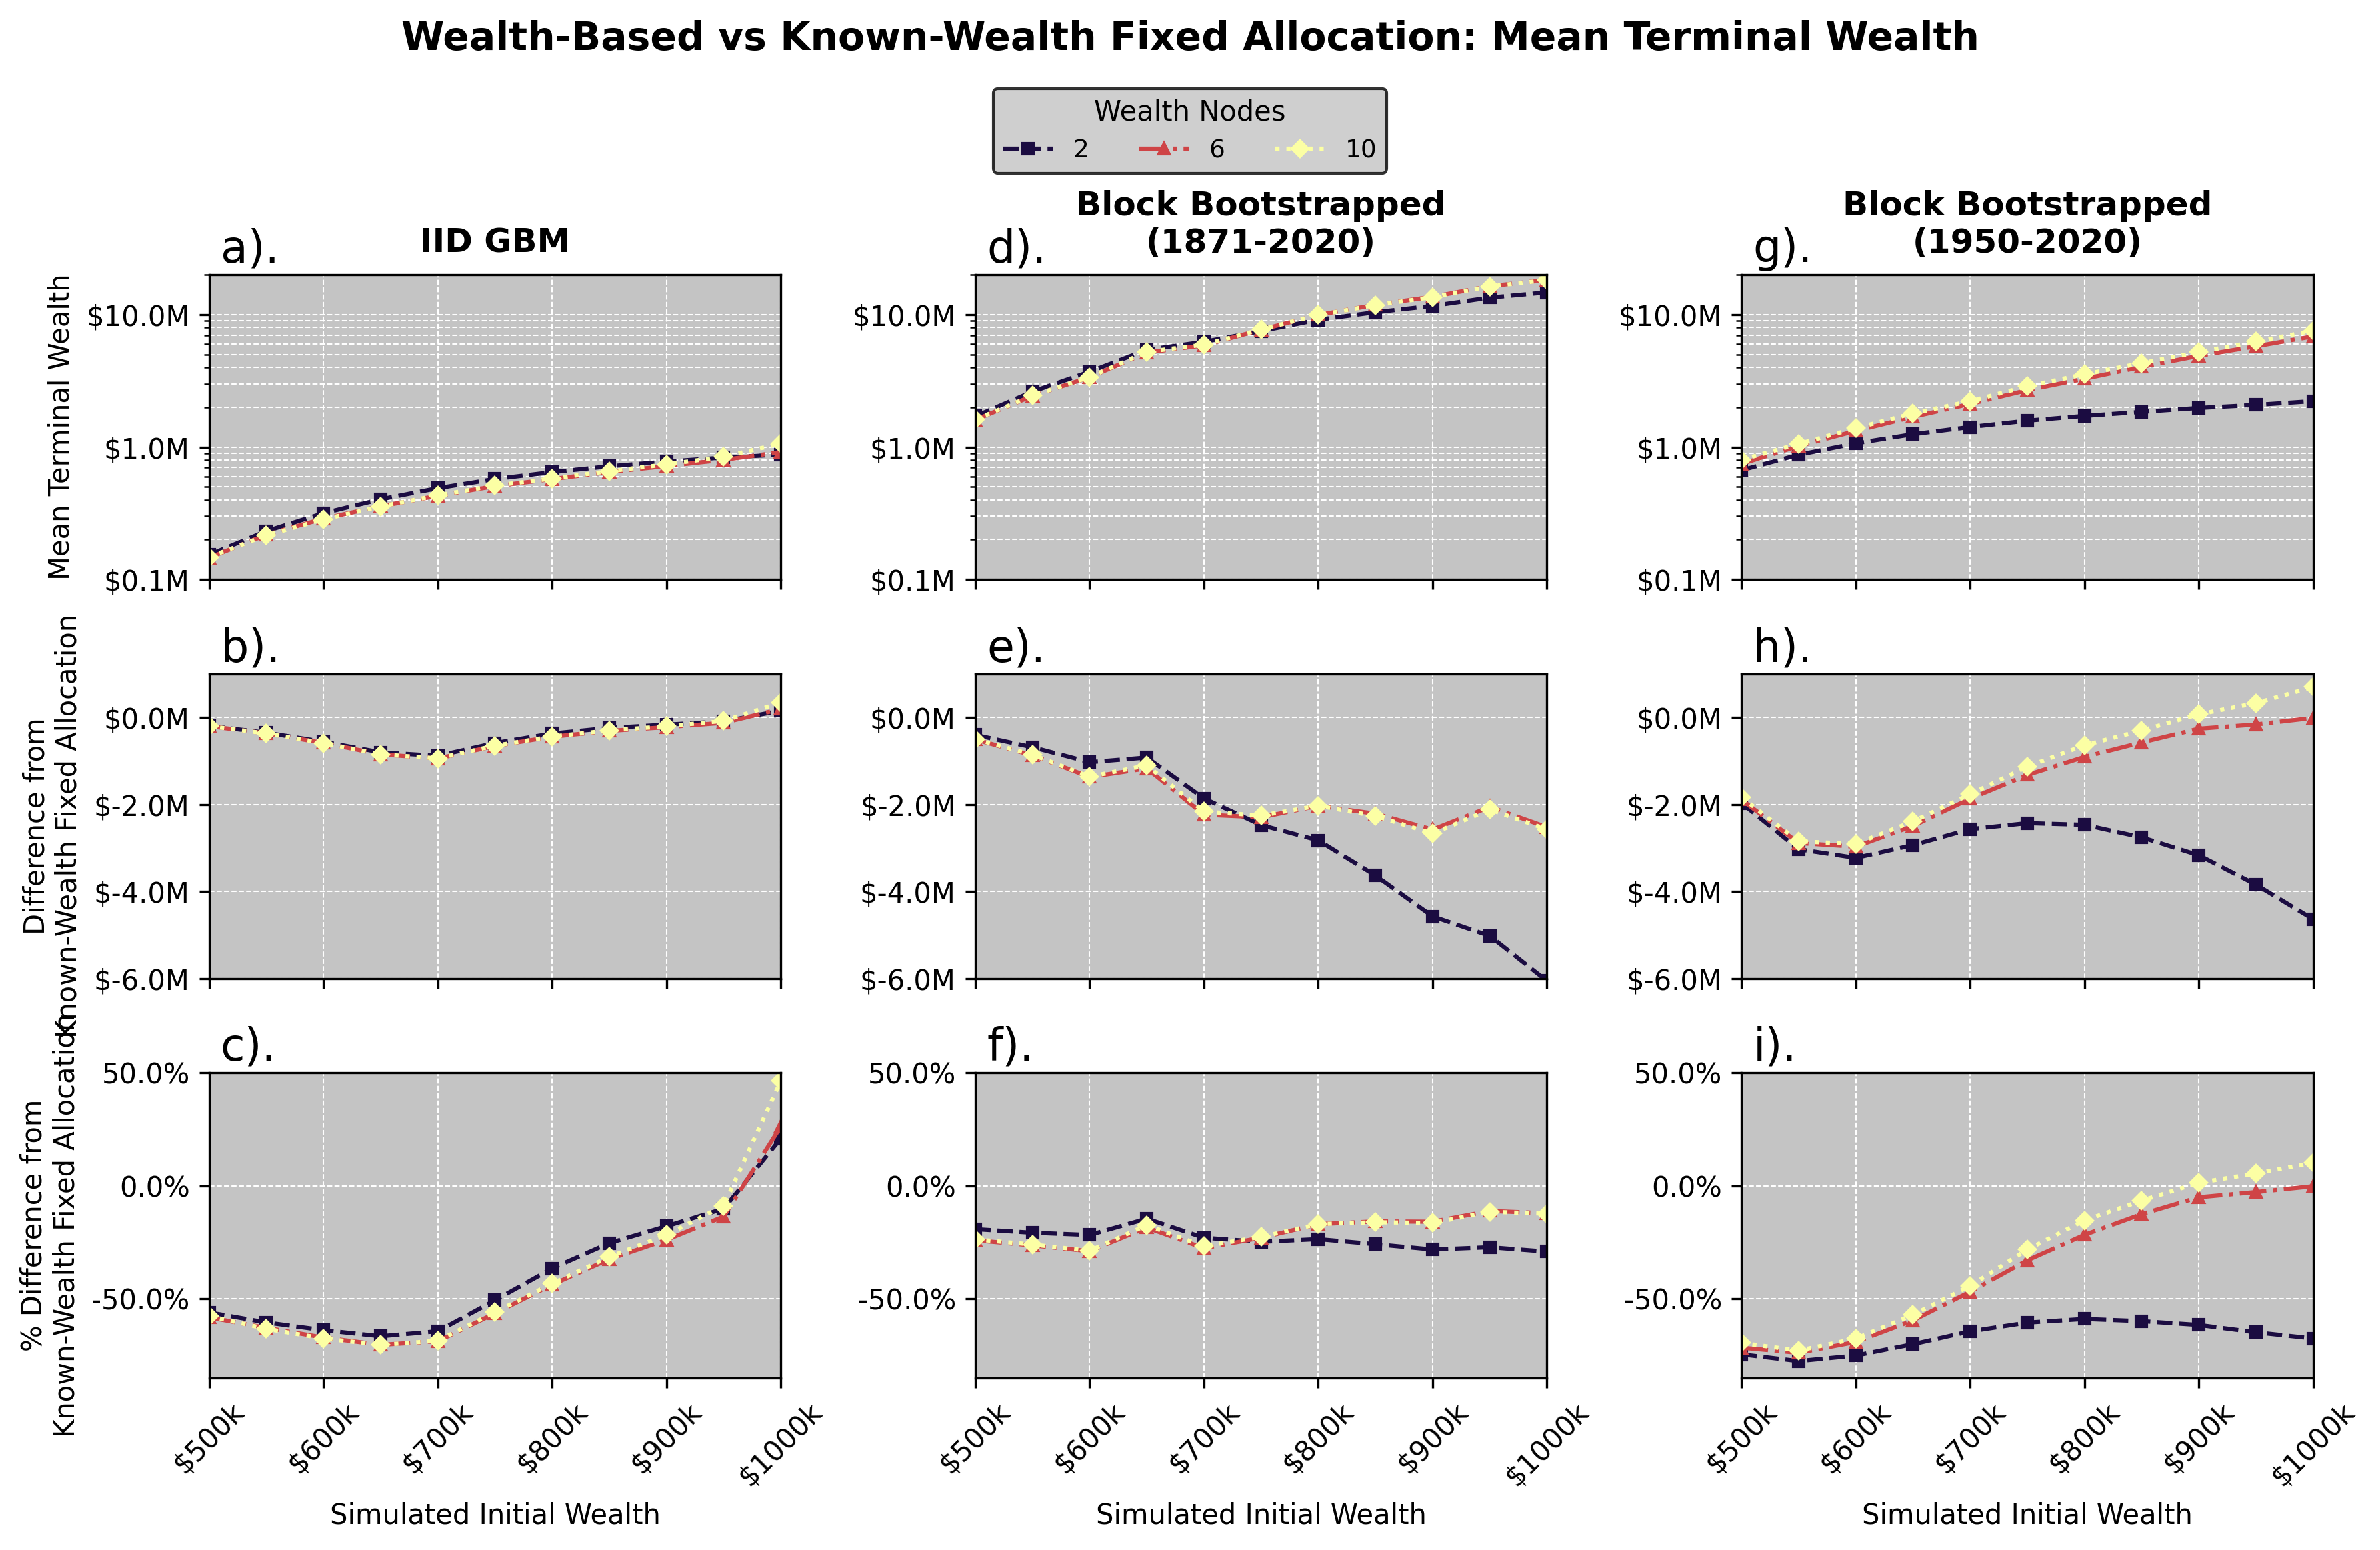

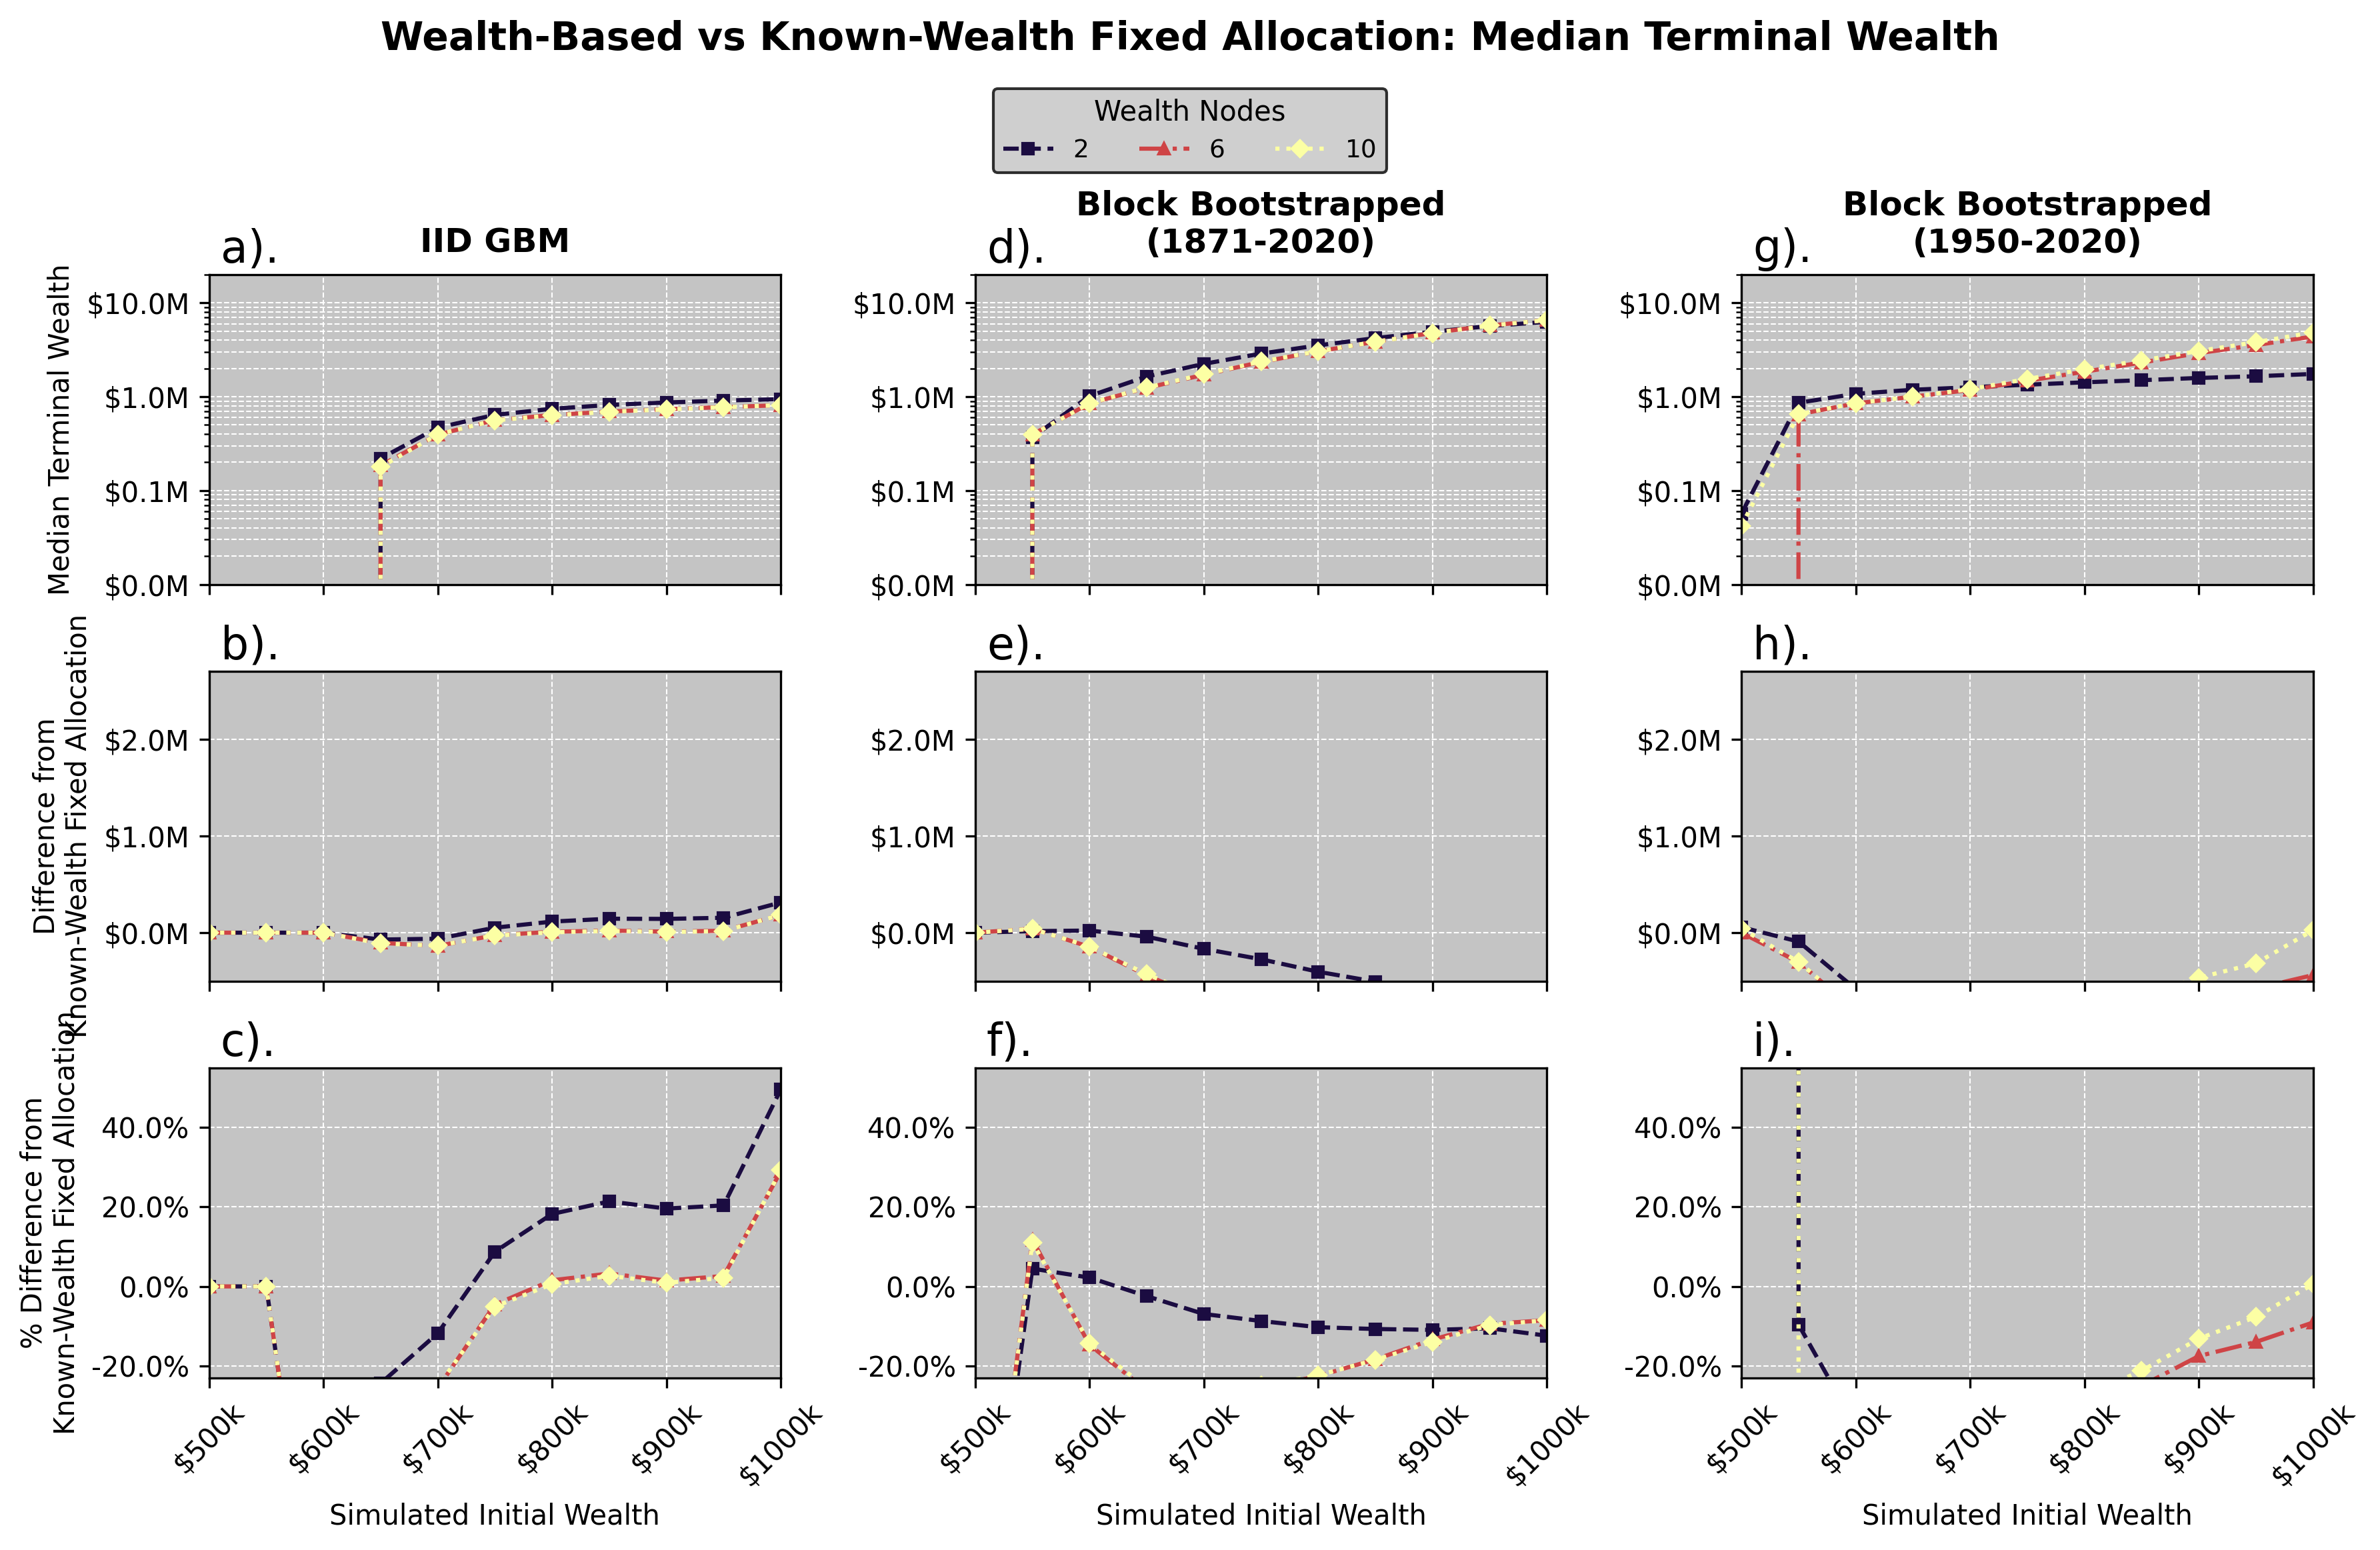

In [31]:
def plot_metric_vs_known_wealth_fixed_baseline(
    outcome_node_data: pl.DataFrame,
    fixed_baseline_data: pl.DataFrame,
    nodes_to_plot: list[int],
    samplers_to_plot: list[str],
    metric: str = 'bankruptcy_density',
    metric_label: str | None = None,
    diff_label: str = 'Difference from Fixed Baseline',
    rel_diff_label: str = 'Relative Difference from Fixed Baseline',
    top_ylim: tuple[float, float] | None = None,
    diff_ylim: tuple[float, float] | None = None,
    rel_diff_ylim: tuple[float, float] | None = None,
    top_as_percent: bool = True,
    diff_as_percent: bool = True,
    rel_diff_as_percent: bool = True,
) -> tuple[plt.Figure, np.ndarray]:
    fig, axes = plt.subplots(
        3,
        len(samplers_to_plot),
        figsize=(12, 7),
        dpi=300,
        squeeze=True,
        sharex=True,
    )

    linestyles = [None, '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 1))]
    markers = ['o', 's', '^', 'D', 'v', '*']

    if len(samplers_to_plot) == 1:
        axes = axes.reshape(3, 1)

    metric_label = metric_label or metric.replace('_', ' ').title()
    denom = max(nodes_to_plot) - min(nodes_to_plot)

    for j, sampler in enumerate(samplers_to_plot):
        ax1: plt.Axes = axes[0, j]
        ax2: plt.Axes = axes[1, j]
        ax3: plt.Axes = axes[2, j]

        baseline_data = fixed_baseline_data.filter(pl.col('sampler') == sampler).sort('simulated_initial_wealth')
        baseline_x = np.asarray(baseline_data['simulated_initial_wealth'].to_list(), dtype=float)
        baseline_y = np.asarray(baseline_data[metric].to_list(), dtype=float)

        baseline_mask = np.isfinite(baseline_x) & np.isfinite(baseline_y)
        baseline_x = baseline_x[baseline_mask]
        baseline_y = baseline_y[baseline_mask]
        baseline_key = _wealth_bucket_key(baseline_x)

        sampler_common_x = []

        for n in nodes_to_plot:
            this_data = outcome_node_data.filter(
                (pl.col('sampler') == sampler)
                & (pl.col('n_wealth_nodes') == n)
            ).sort('simulated_initial_wealth')

            x = np.asarray(this_data['simulated_initial_wealth'].to_list(), dtype=float)
            y = np.asarray(this_data[metric].to_list(), dtype=float)

            mask = np.isfinite(x) & np.isfinite(y)
            x = x[mask]
            y = y[mask]
            x_key = _wealth_bucket_key(x)

            common_key, base_idx, this_idx = np.intersect1d(baseline_key, x_key, return_indices=True)
            if common_key.size == 0:
                print(
                    f"Warning: no overlapping simulated_initial_wealth buckets for sampler '{sampler}' and n_wealth_nodes {n}. Skipping."
                )
                continue

            common_x = baseline_x[base_idx]
            baseline_y_aligned = baseline_y[base_idx]
            y_aligned = y[this_idx]

            diff_abs = y_aligned - baseline_y_aligned
            diff_rel = np.divide(
                y_aligned,
                baseline_y_aligned,
                out=np.full_like(y_aligned, 1, dtype=float),
                where=baseline_y_aligned != 0,
            ) - 1.0

            c = plt.cm.inferno(0.5 if denom == 0 else (n - min(nodes_to_plot)) / denom)
            linestyle = linestyles[nodes_to_plot.index(n) % len(linestyles)]
            marker = markers[nodes_to_plot.index(n) % len(markers)]

            ax1.plot(
                common_x,
                y_aligned,
                marker=marker,
                markersize=4,
                label=f'{n}',
                color=c,
                linestyle=linestyle,
            )

            sampler_common_x.append(common_x)

            ax2.plot(
                common_x,
                diff_abs,
                marker=marker,
                markersize=4,
                label=f'{n}',
                color=c,
                linestyle=linestyle,
            )

            ax3.plot(
                common_x,
                diff_rel,
                marker=marker,
                markersize=4,
                label=f'{n}',
                color=c,
                linestyle=linestyle,
            )

        if sampler_common_x:
            x_joined = np.concatenate(sampler_common_x)
            x_min = float(np.nanmin(x_joined))
            x_max = float(np.nanmax(x_joined))
        else:
            fallback_x = np.asarray(
                fixed_baseline_data.filter(pl.col('sampler') == sampler)['simulated_initial_wealth'].to_list(),
                dtype=float,
            )
            fallback_x = fallback_x[np.isfinite(fallback_x)]
            if fallback_x.size > 0:
                x_min = float(np.nanmin(fallback_x))
                x_max = float(np.nanmax(fallback_x))
            else:
                x_min, x_max = 0.0, 1.0

        ax1.set_xlim(x_min, x_max)
        ax2.set_xlim(x_min, x_max)
        ax3.set_xlim(x_min, x_max)

        ax1.text(0.02, 1.01, get_plot_letter(j, 0, samplers_to_plot), transform=ax1.transAxes, fontsize=16, va='bottom', ha='left')
        ax2.text(0.02, 1.01, get_plot_letter(j, 1, samplers_to_plot), transform=ax2.transAxes, fontsize=16, va='bottom', ha='left')
        ax3.text(0.02, 1.01, get_plot_letter(j, 2, samplers_to_plot), transform=ax3.transAxes, fontsize=16, va='bottom', ha='left')

        if top_ylim is not None:
            ax1.set_ylim(*top_ylim)
        if diff_ylim is not None:
            ax2.set_ylim(*diff_ylim)
        if rel_diff_ylim is not None:
            ax3.set_ylim(*rel_diff_ylim)

        if top_as_percent:
            ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
        if diff_as_percent:
            ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
        if rel_diff_as_percent:
            ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))

        ax1.set_title(RETURN_SAMPLER_DISPLAY_NAMES[sampler], fontsize=12, fontweight='bold', pad=8)
        ax3.set_xlabel('Simulated Initial Wealth', fontsize=10)

    for plot in axes.flatten():
        plot.grid(True, which='both', linestyle='--', linewidth=0.5, color='white')
        plot.set_facecolor('#c4c4c4')

    axes[0, 0].set_ylabel(metric_label, fontsize=10)
    axes[1, 0].set_ylabel(diff_label, fontsize=10)
    axes[2, 0].set_ylabel(rel_diff_label, fontsize=10)

    def _safe_k_formatter(x: float, _: int) -> str:
        if not np.isfinite(x):
            return ''
        return f'${int(x/1000)}k'

    for j in range(len(samplers_to_plot)):
        axes[2, j].xaxis.set_major_formatter(plt.FuncFormatter(_safe_k_formatter))
        axes[2, j].tick_params(axis='x', rotation=45)

    fig.tight_layout()

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles=handles,
            labels=labels,
            loc='upper center',
            bbox_to_anchor=(0.5, 1.06),
            ncol=len(nodes_to_plot),
            fontsize=9,
            frameon=True,
            title='Wealth Nodes',
            title_fontsize=10,
            facecolor='#c4c4c4',
            edgecolor='black',
        )

    return fig, axes


# Wealth-based outcomes (distributed initial wealth, varying wealth-node resolution).
outcome_node_compare = outcomes_df.join(
    experiment_df,
    on='experiment_file',
).filter(
    (pl.col('n_time_nodes') == 1)
    & (pl.col('n_wealth_nodes').is_in([2, 6, 10]))
    & (pl.col('initial_wealth').is_null())
)

# Fixed-policy known-in-advance baseline outcomes.
fixed_known_baseline = outcomes_df.join(
    experiment_df,
    on='experiment_file',
).filter(
    (pl.col('n_time_nodes') == 1)
    & (pl.col('n_wealth_nodes') == 1)
    & (pl.col('initial_wealth').is_not_null())
)

nodes_to_plot = [1, 2, 6, 10]

fig, axes = plot_metric_vs_known_wealth_fixed_baseline(
    outcome_node_data=outcome_node_compare,
    fixed_baseline_data=fixed_known_baseline,
    nodes_to_plot=nodes_to_plot,
    samplers_to_plot=samplers_to_plot,
    metric='bankruptcy_density',
    metric_label='Bankruptcy Density',
    diff_label='Difference from\nKnown-Wealth Fixed Allocation',
    rel_diff_label='% Difference from\nKnown-Wealth Fixed Allocation',
    top_ylim=(0, 0.4),
    diff_ylim=(-0.022, 0.002),
    rel_diff_ylim=(-0.32, .2),
    top_as_percent=True,
    diff_as_percent=True,
    rel_diff_as_percent=True,
)
plt.suptitle('Wealth-Based vs Known-Wealth Fixed Allocation: Bankruptcy Density', fontsize=14, fontweight='bold', y=1.1)
plt.savefig('./Plots/Wealth_Based_vs_Known_Wealth_Fixed_Bankruptcy_Density_Comparison.png', dpi=400, bbox_inches='tight', pad_inches=0.2)

fig, axes = plot_metric_vs_known_wealth_fixed_baseline(
    outcome_node_data=outcome_node_compare,
    fixed_baseline_data=fixed_known_baseline,
    nodes_to_plot=nodes_to_plot,
    samplers_to_plot=samplers_to_plot,
    metric='bankruptcy_probability',
    metric_label='Bankruptcy Probability',
    diff_label='Difference from\nKnown-Wealth Fixed Allocation',
    rel_diff_label='% Difference from\nKnown-Wealth Fixed Allocation',
    top_ylim=(0, 0.7),
    diff_ylim=(-0.04, 0.02),
    rel_diff_ylim=(-0.32, 0.05),
    top_as_percent=True,
    diff_as_percent=True,
    rel_diff_as_percent=True,
)
plt.suptitle('Wealth-Based vs Known-Wealth Fixed Allocation: Bankruptcy Probability', fontsize=14, fontweight='bold', y=1.1)
plt.savefig('./Plots/Wealth_Based_vs_Known_Wealth_Fixed_Bankruptcy_Probability_Comparison.png', dpi=400, bbox_inches='tight', pad_inches=0.2)

fig, axes = plot_metric_vs_known_wealth_fixed_baseline(
    outcome_node_data=outcome_node_compare,
    fixed_baseline_data=fixed_known_baseline,
    nodes_to_plot=nodes_to_plot,
    samplers_to_plot=samplers_to_plot,
    metric='mean_terminal_wealth',
    metric_label='Mean Terminal Wealth',
    diff_label='Difference from\nKnown-Wealth Fixed Allocation',
    rel_diff_label='% Difference from\nKnown-Wealth Fixed Allocation',
    top_ylim=(1e5, 2e7),
    diff_ylim=(-6e6, 1e6),
    rel_diff_ylim=(-0.85, 0.5),
    top_as_percent=False,
    diff_as_percent=False,
)
for j in range(len(samplers_to_plot)):
    axes[0, j].set_yscale('log')
currency_fmt = plt.FuncFormatter(lambda y, _: f'${y/1_000_000:.1f}M' if np.isfinite(y) else '')
for j in range(len(samplers_to_plot)):
    axes[0, j].yaxis.set_major_formatter(currency_fmt)
    axes[1, j].yaxis.set_major_formatter(currency_fmt)
plt.suptitle('Wealth-Based vs Known-Wealth Fixed Allocation: Mean Terminal Wealth', fontsize=14, fontweight='bold', y=1.1)
plt.savefig('./Plots/Wealth_Based_vs_Known_Wealth_Fixed_Mean_Terminal_Wealth_Comparison.png', dpi=400, bbox_inches='tight', pad_inches=0.2)

fig, axes = plot_metric_vs_known_wealth_fixed_baseline(
    outcome_node_data=outcome_node_compare.with_columns(pl.col('median_terminal_wealth').cast(pl.Int64)),
    fixed_baseline_data=fixed_known_baseline,
    nodes_to_plot=nodes_to_plot,
    samplers_to_plot=samplers_to_plot,
    metric='median_terminal_wealth',
    metric_label='Median Terminal Wealth',
    diff_label='Difference from\nKnown-Wealth Fixed Allocation',
    rel_diff_label='% Difference from\nKnown-Wealth Fixed Allocation',
    top_ylim=(1e4, 2e7),
    diff_ylim=(-5e5, 2.7e6),
    rel_diff_ylim=(-0.23, 0.55),
    top_as_percent=False,
    diff_as_percent=False,
)
for j in range(len(samplers_to_plot)):
    axes[0, j].set_yscale('log')
for j in range(len(samplers_to_plot)):
    axes[0, j].yaxis.set_major_formatter(currency_fmt)
    axes[1, j].yaxis.set_major_formatter(currency_fmt)
plt.suptitle('Wealth-Based vs Known-Wealth Fixed Allocation: Median Terminal Wealth', fontsize=14, fontweight='bold', y=1.1)
plt.savefig('./Plots/Wealth_Based_vs_Known_Wealth_Fixed_Median_Terminal_Wealth_Comparison.png', dpi=400, bbox_inches='tight', pad_inches=0.2)

plt.show()

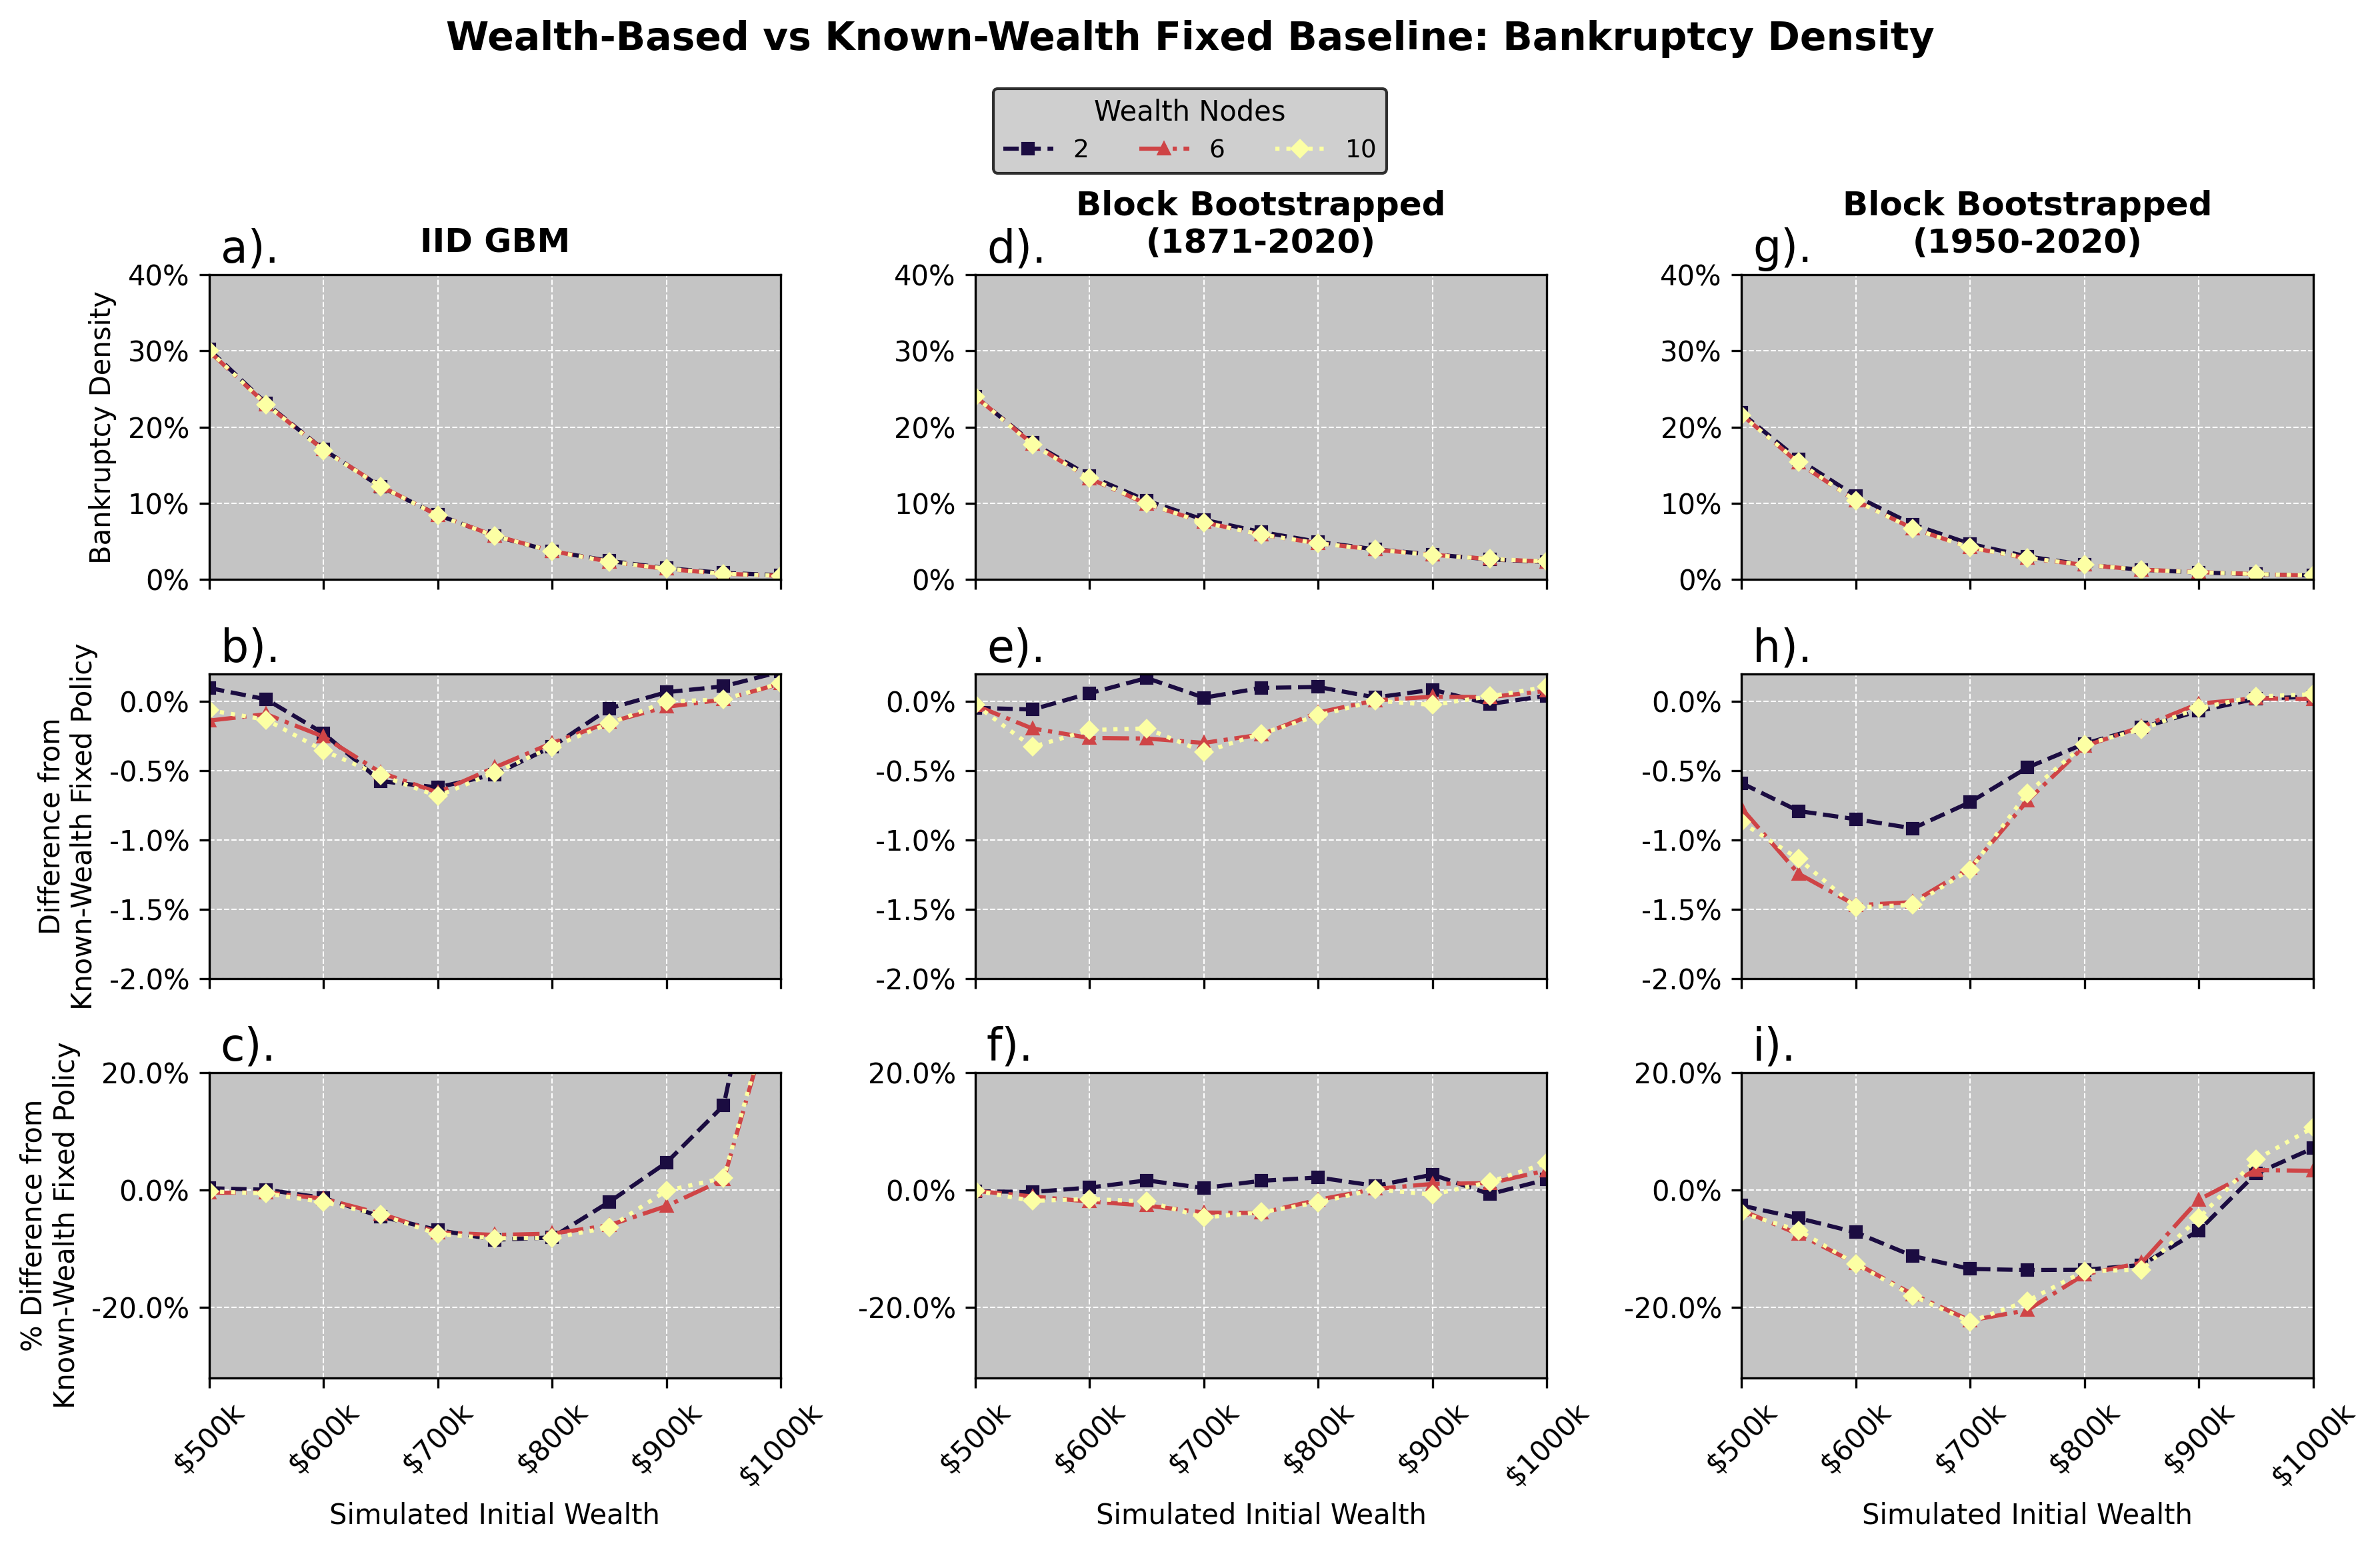

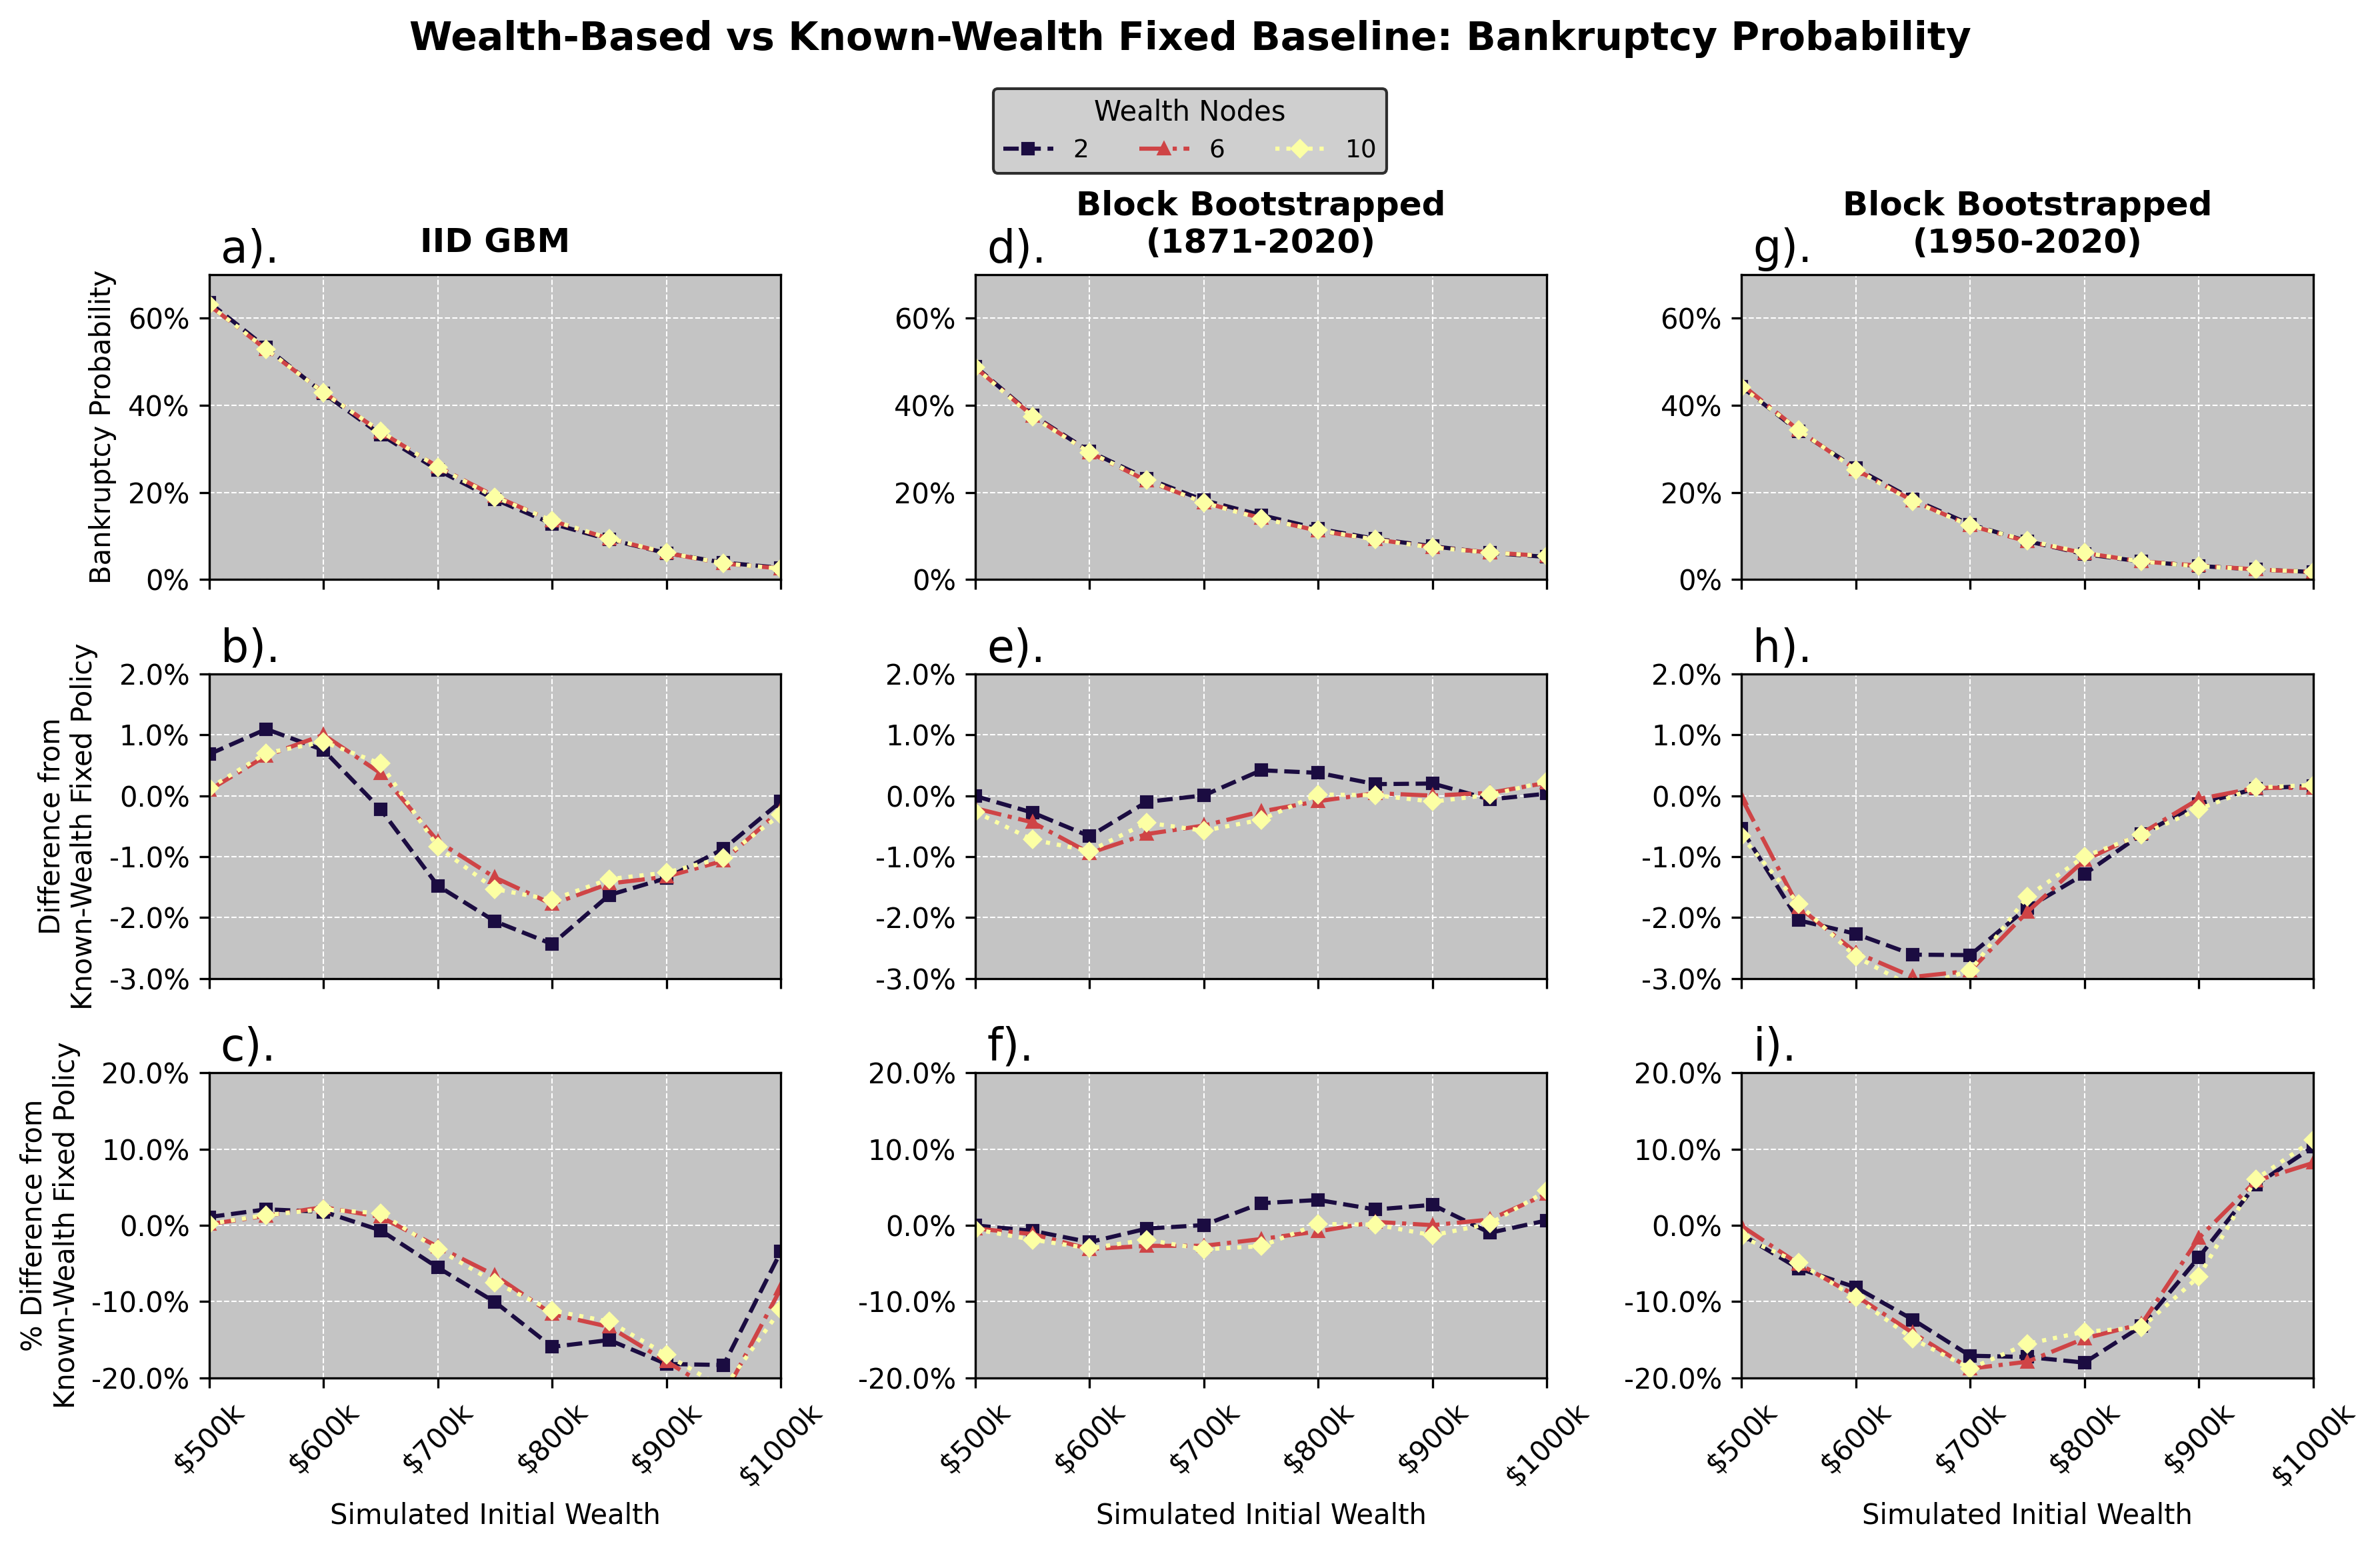

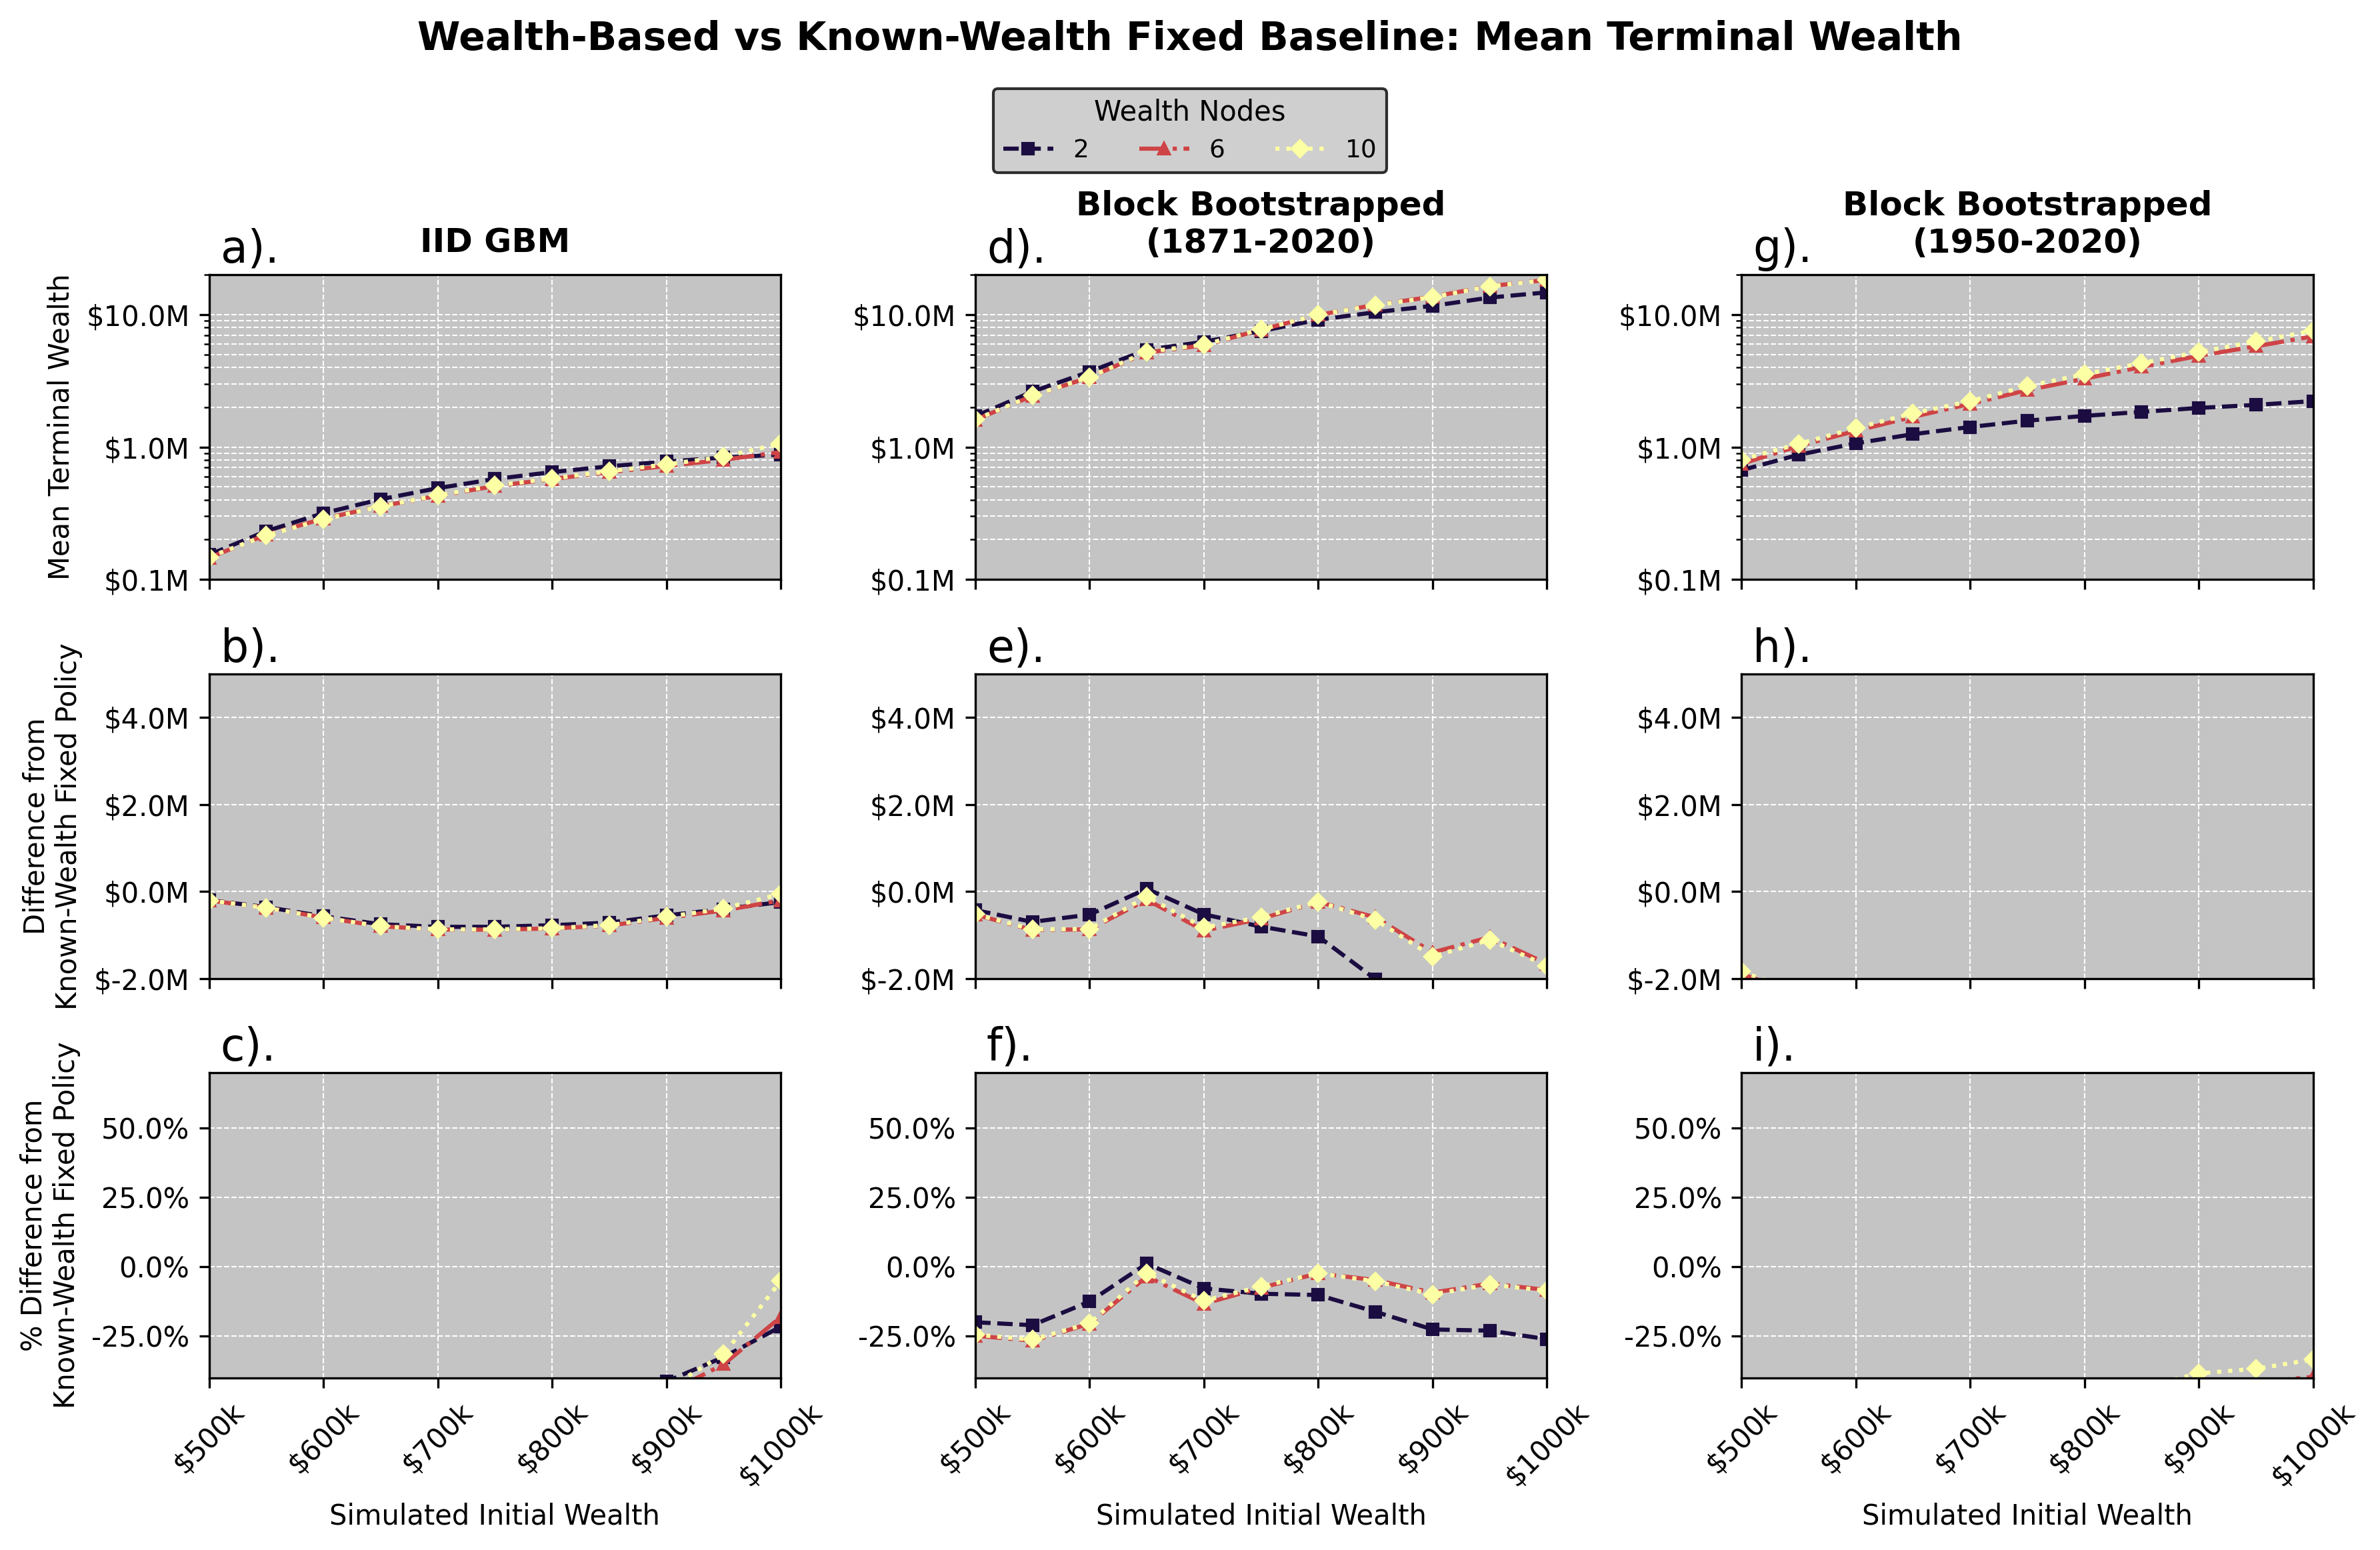

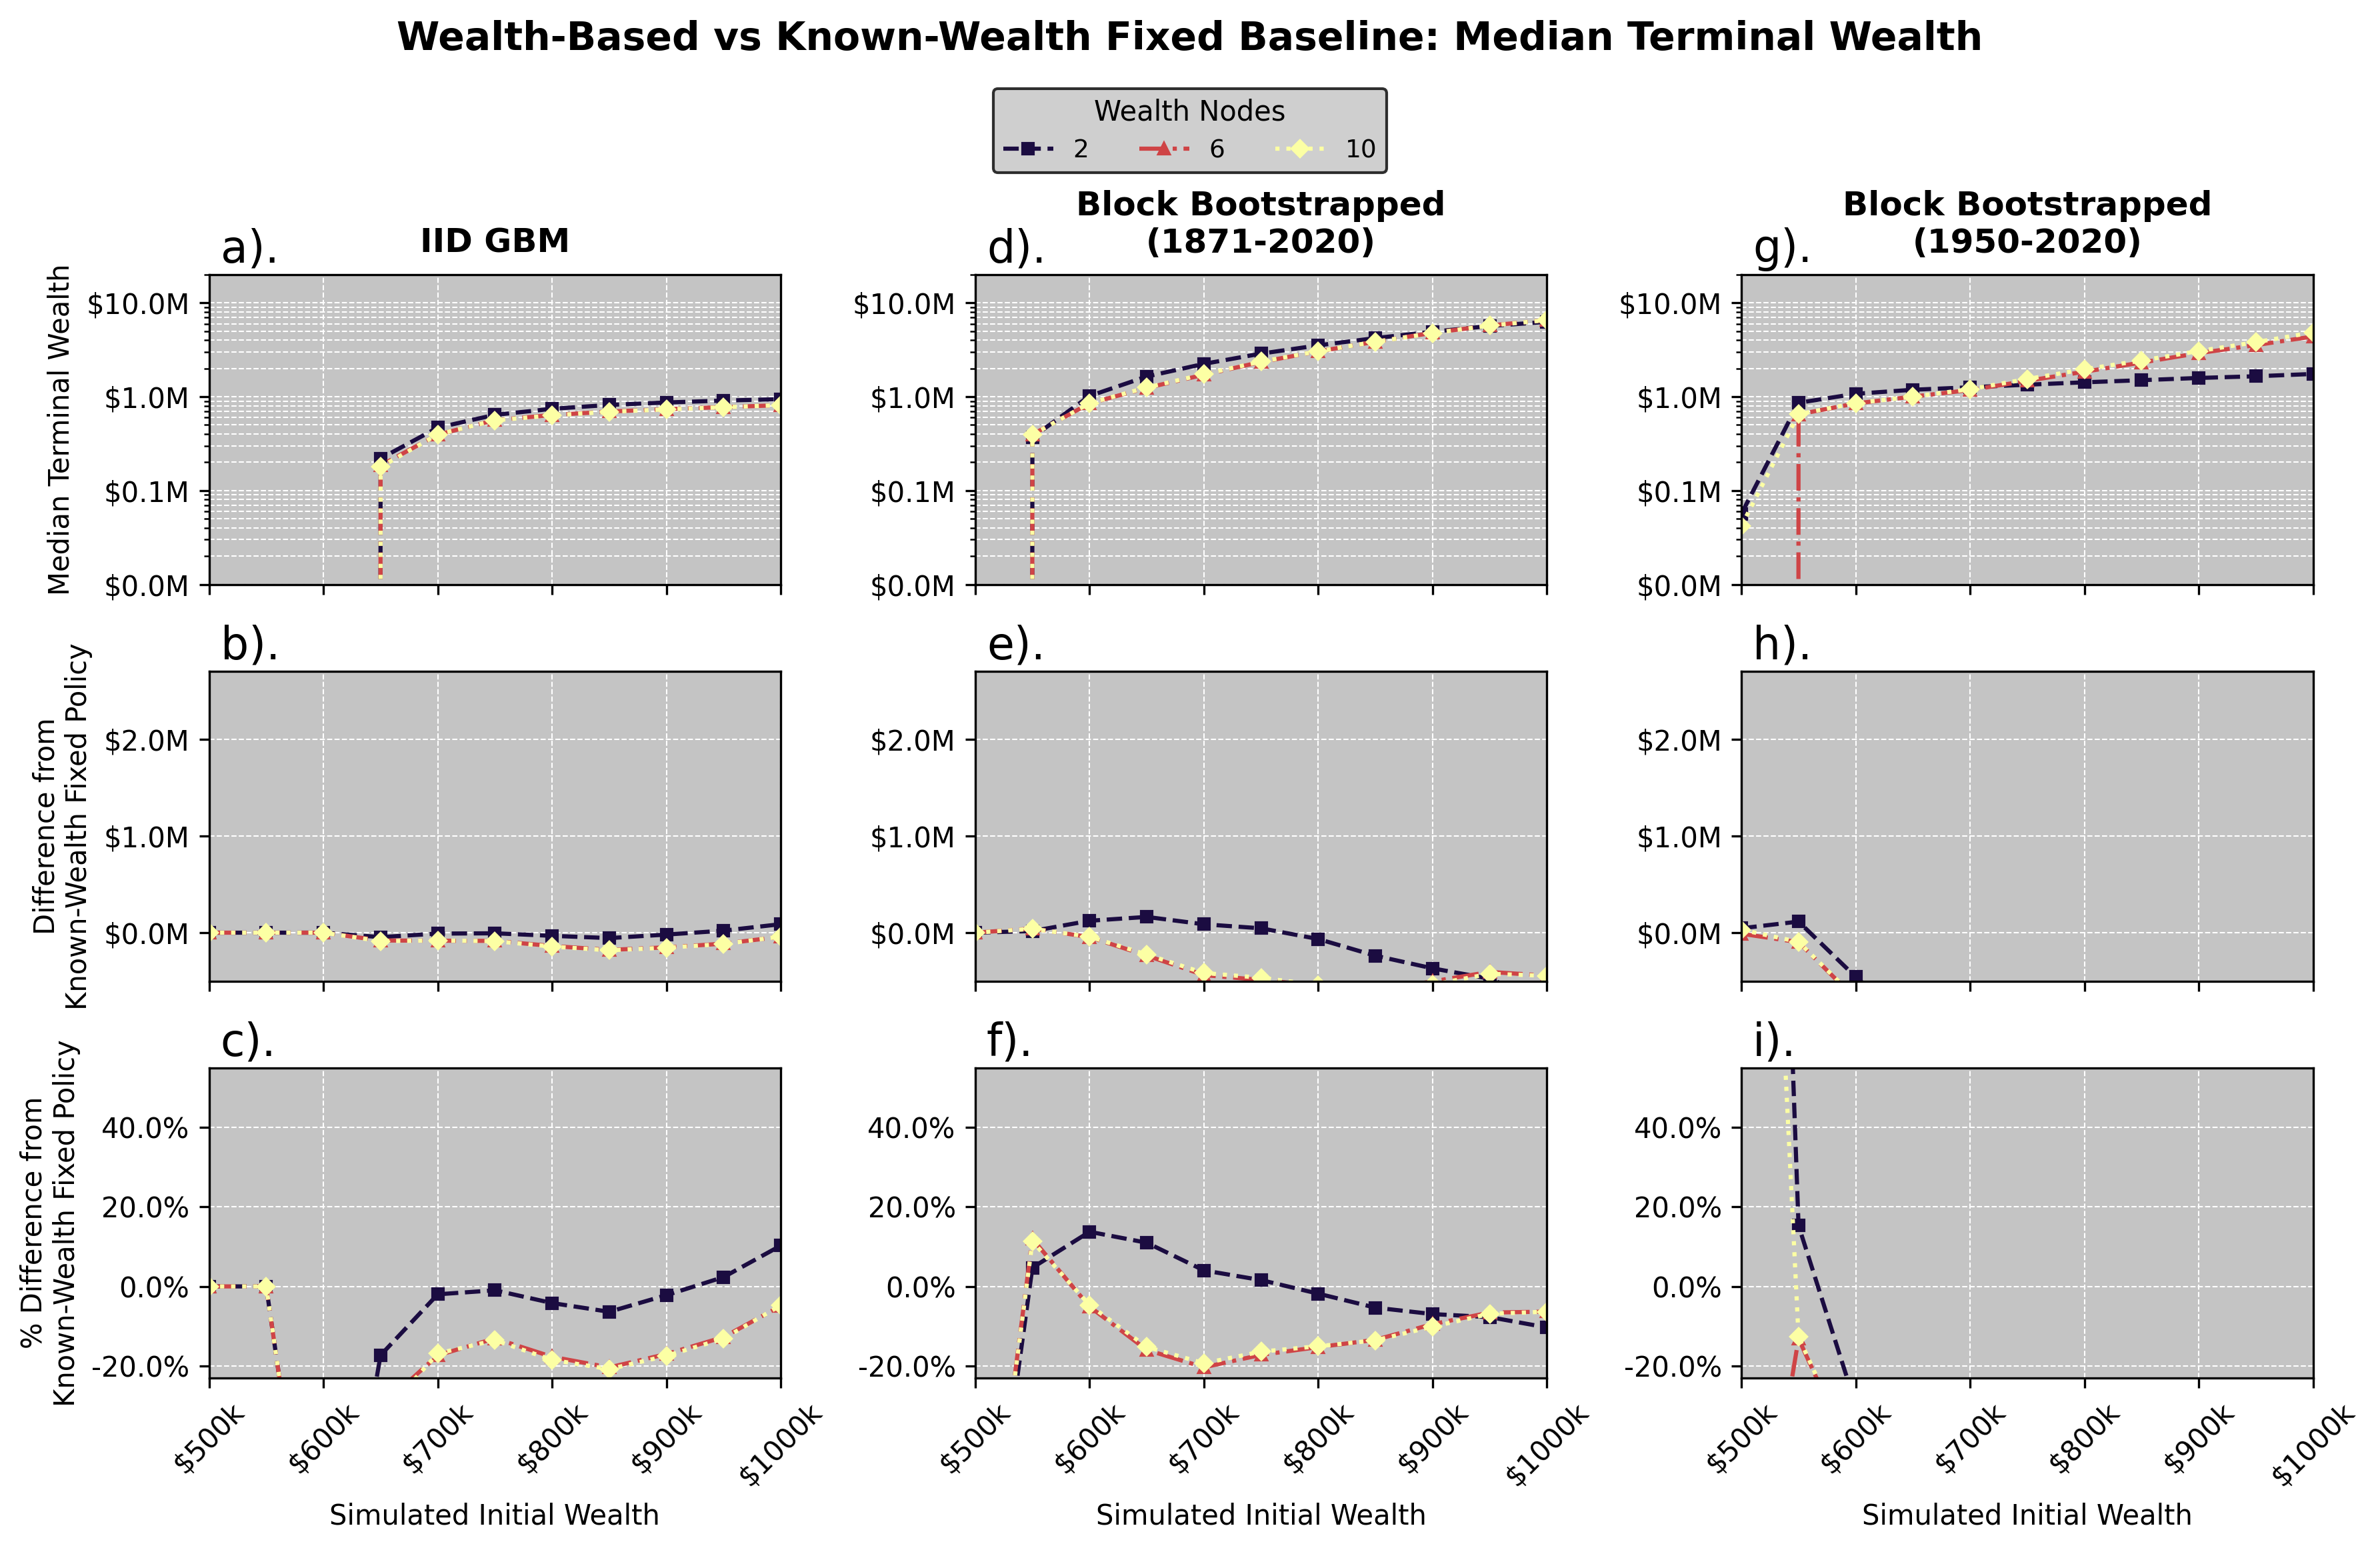

In [ ]:

# Wealth-based outcomes (distributed initial wealth, varying wealth-node resolution).
outcome_node_compare = outcomes_df.join(
    experiment_df,
    on='experiment_file',
).filter(
    (pl.col('n_time_nodes') == 1)
    & (pl.col('n_wealth_nodes').is_in([2, 6, 10]))
    & (pl.col('initial_wealth').is_null())
)

# Time based policy known-in-advance baseline outcomes.
fixed_known_baseline = outcomes_df.join(
    experiment_df,
    on='experiment_file',
).filter(
    (pl.col('n_time_nodes') == 8)
    & (pl.col('n_wealth_nodes') == 1)
    & (pl.col('initial_wealth').is_not_null())
)

nodes_to_plot = [1, 2, 6, 10]

fig, axes = plot_metric_vs_known_wealth_fixed_baseline(
    outcome_node_data=outcome_node_compare,
    fixed_baseline_data=fixed_known_baseline,
    nodes_to_plot=nodes_to_plot,
    samplers_to_plot=samplers_to_plot,
    metric='bankruptcy_density',
    metric_label='Bankruptcy Density',
    diff_label='Difference from\nKnown-Wealth Fixed Allocation',
    rel_diff_label='% Difference from\nKnown-Wealth Fixed Allocation',
    top_ylim=(0, 0.4),
    diff_ylim=(-0.02, 0.002),
    rel_diff_ylim=(-0.32, .2),
    top_as_percent=True,
    diff_as_percent=True,
    rel_diff_as_percent=True,
)
plt.suptitle('Wealth-Based vs Known-Wealth Fixed Baseline: Bankruptcy Density', fontsize=14, fontweight='bold', y=1.1)
plt.savefig('./Plots/Wealth_Based_vs_Known_Wealth_Fixed_Bankruptcy_Density_Comparison.png', dpi=400, bbox_inches='tight', pad_inches=0.2)

fig, axes = plot_metric_vs_known_wealth_fixed_baseline(
    outcome_node_data=outcome_node_compare,
    fixed_baseline_data=fixed_known_baseline,
    nodes_to_plot=nodes_to_plot,
    samplers_to_plot=samplers_to_plot,
    metric='bankruptcy_probability',
    metric_label='Bankruptcy Probability',
    diff_label='Difference from\nKnown-Wealth Fixed Policy',
    rel_diff_label='% Difference from\nKnown-Wealth Fixed Policy',
    top_ylim=(0, 0.7),
    diff_ylim=(-0.032, 0.02),
    rel_diff_ylim=(-0.22, 0.12),
    top_as_percent=True,
    diff_as_percent=True,
    rel_diff_as_percent=True,
)
plt.suptitle('Wealth-Based vs Known-Wealth Fixed Baseline: Bankruptcy Probability', fontsize=14, fontweight='bold', y=1.1)
plt.savefig('./Plots/Wealth_Based_vs_Known_Wealth_Fixed_Bankruptcy_Probability_Comparison.png', dpi=400, bbox_inches='tight', pad_inches=0.2)

fig, axes = plot_metric_vs_known_wealth_fixed_baseline(
    outcome_node_data=outcome_node_compare,
    fixed_baseline_data=fixed_known_baseline,
    nodes_to_plot=nodes_to_plot,
    samplers_to_plot=samplers_to_plot,
    metric='mean_terminal_wealth',
    metric_label='Mean Terminal Wealth',
    diff_label='Difference from\nKnown-Wealth Fixed Policy',
    rel_diff_label='% Difference from\nKnown-Wealth Fixed Policy',
    top_ylim=(1e5, 2e7),
    diff_ylim=(-2e6, 5e6),
    rel_diff_ylim=(-0.4, 0.7),
    top_as_percent=False,
    diff_as_percent=False,
)
for j in range(len(samplers_to_plot)):
    axes[0, j].set_yscale('log')
currency_fmt = plt.FuncFormatter(lambda y, _: f'${y/1_000_000:.1f}M' if np.isfinite(y) else '')
for j in range(len(samplers_to_plot)):
    axes[0, j].yaxis.set_major_formatter(currency_fmt)
    axes[1, j].yaxis.set_major_formatter(currency_fmt)
plt.suptitle('Wealth-Based vs Known-Wealth Fixed Baseline: Mean Terminal Wealth', fontsize=14, fontweight='bold', y=1.1)
plt.savefig('./Plots/Wealth_Based_vs_Known_Wealth_Fixed_Mean_Terminal_Wealth_Comparison.png', dpi=400, bbox_inches='tight', pad_inches=0.2)

fig, axes = plot_metric_vs_known_wealth_fixed_baseline(
    outcome_node_data=outcome_node_compare.with_columns(pl.col('median_terminal_wealth').cast(pl.Int64)),
    fixed_baseline_data=fixed_known_baseline,
    nodes_to_plot=nodes_to_plot,
    samplers_to_plot=samplers_to_plot,
    metric='median_terminal_wealth',
    metric_label='Median Terminal Wealth',
    diff_label='Difference from\nKnown-Wealth Fixed Policy',
    rel_diff_label='% Difference from\nKnown-Wealth Fixed Policy',
    top_ylim=(1e4, 2e7),
    diff_ylim=(-5e5, 2.7e6),
    rel_diff_ylim=(-0.23, 0.55),
    top_as_percent=False,
    diff_as_percent=False,
)
for j in range(len(samplers_to_plot)):
    axes[0, j].set_yscale('log')
for j in range(len(samplers_to_plot)):
    axes[0, j].yaxis.set_major_formatter(currency_fmt)
    axes[1, j].yaxis.set_major_formatter(currency_fmt)
plt.suptitle('Wealth-Based vs Known-Wealth Fixed Baseline: Median Terminal Wealth', fontsize=14, fontweight='bold', y=1.1)
plt.savefig('./Plots/Wealth_Based_vs_Known_Wealth_Fixed_Median_Terminal_Wealth_Comparison.png', dpi=400, bbox_inches='tight', pad_inches=0.2)

plt.show()